In [1]:
requiredPackages = c('ggsci',
                     'tidyverse',
                     'data.table',
                     'patchwork',
                     'ggpubr',
                     'ggbreak',
                     'qqman',
                     'ComplexHeatmap',
                     'circlize',
                     'viridis',
                     'cowplot',
                     'ggplotify',
                     'tiff'
                    )
for(p in requiredPackages){
  if(!require(p,character.only = TRUE)) install.packages(p)
  library(p,character.only = TRUE)
}

colorBlindBlack8  <- c("#000000", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7")

Loading required package: ggsci

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: data.table


Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose


Loading required package: patchwor

In [2]:
# system(paste0("gsutil cp gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/scripts/r/functions/compare_gwas_sumstats.R ."),
#        intern=T)

# source("compare_gwas_sumstats.R")

In [3]:
fread_gcs_tsv <- function(gcs_path, ...) {
  # Create a temporary file
  temp_file <- tempfile(fileext = ".tsv")
  on.exit(unlink(temp_file), add = TRUE)

  # Copy the file from GCS to the temp file
  gsutil_cmd <- sprintf("gsutil cp '%s' '%s'", gcs_path, temp_file)
  status <- system(gsutil_cmd, ignore.stderr = TRUE)

  if (status != 0) {
    stop(sprintf("Failed to copy file from GCS: %s", gcs_path))
  }

  # Read with fread
  dt <- fread(temp_file, ...)
  return(dt)
}

In [4]:
rename_column <- function(
    df,
    columns,
    new.name
){
  col_names <- names(df)
  
  # Check for columns in a case insensitive manner
  chr_col <- grep(paste0("^(",paste(columns, collapse = "|"),")$"),
                  col_names,
                  ignore.case = TRUE,
                  value = TRUE)
  
  if(length(chr_col) == 1) {
    names(df)[names(df) == chr_col] <- new.name
  }
  
  return(df)
}

merge_gwas_sumstats <- function(
    df1, # First dataframe and its columns
    chr1 = NULL,
    snp1 = NULL,
    effect_allele1 = NULL,
    other_allele1 = NULL,
    beta1 = NULL,
    se1 = NULL,
    z1 = NULL,
    p_log1 = c(NULL, NULL), # (p-value column, is log?)
    suffix1 = NULL,
    df2, # Second dataframe and its columns
    chr2 = NULL,
    snp2 = NULL,
    effect_allele2 = NULL,
    other_allele2 = NULL,
    beta2 = NULL,
    se2 = NULL,
    z2 = NULL,
    p_log2 = c(NULL, NULL), # (p-value column, is log?)
    suffix2 = NULL,
    cutoff = NULL
){
  
  # Apply the cutoff
  if(!(missing(cutoff) | is.null(cutoff))){
    if(cutoff > 0){
      if(isTRUE(p_log1[2]) | p_log1[2] == "TRUE"){
        df1 <- df1 %>% dplyr::filter(!!sym(p_log1[1]) > -log10(cutoff))
      } else {
        df1 <- df1 %>% dplyr::filter(!!sym(p_log1[1]) < cutoff)
      }
      
      if(isTRUE(p_log2[2]) | p_log2[2] == "TRUE"){
        df2 <- df2 %>% dplyr::filter(!!sym(p_log2[1]) > -log10(cutoff))
      } else {
        df2 <- df2 %>% dplyr::filter(!!sym(p_log2[1]) < cutoff)
      }
    }
  }
  
  # Rename chr column
  if(missing(chr1) | is.null(chr1)){
    df1 <- rename_column(df1, columns = c("chr", "Chrom", "Chromosome"), new.name = "chr")
  } else {
    df1 <- df1 %>% rename(chr = !!sym(chr1))
  }
  
  if(missing(chr2) | is.null(chr2)){
    df2 <- rename_column(df2, columns = c("chr", "Chrom", "Chromosome"), new.name = "chr")
  } else {
    df2 <- df2 %>% rename(chr = !!sym(chr2))
  }
    
  # Rename MarkerName column
  if(missing(snp1) | is.null(snp1)){
    df1 <- rename_column(df1, columns = c("MarkerName", "SNP", "rsid"), new.name = "snp")
  } else {
    df1 <- df1 %>% rename(snp = !!sym(snp1))
  }
  
  if(missing(snp2) | is.null(snp2)){
    df2 <- rename_column(df2, columns = c("MarkerName", "SNP", "rsid"), new.name = "snp")
  } else {
    df2 <- df2 %>% rename(snp = !!sym(snp2))
  }
  
  # Rename Effect allele column
  if(missing(effect_allele1) | is.null(effect_allele1)){
    df1 <- rename_column(df1, columns = c("effect allele", "effect_allele", "effect"), new.name = "effect_allele")
  } else {
    df1 <- df1 %>% rename(effect_allele = !!sym(effect_allele1))
  }
  
  if(missing(effect_allele2) | is.null(effect_allele2)){
    df2 <- rename_column(df2, columns = c("effect allele", "effect_allele", "effect"), new.name = "effect_allele")
  } else {
    df2 <- df2 %>% rename(effect_allele = !!sym(effect_allele2))
  }
  
  # Rename Other allele column
  if(missing(other_allele1) | is.null(other_allele1)){
    df1 <- rename_column(df1, columns = c("other allele", "other_allele", "other"), new.name = "other_allele")
  } else {
    df1 <- df1 %>% rename(other_allele = !!sym(other_allele1))
  }
  
  if(missing(other_allele2) | is.null(other_allele2)){
    df2 <- rename_column(df2, columns = c("other allele", "other_allele", "other"), new.name = "other_allele")
  } else {
    df2 <- df2 %>% rename(other_allele = !!sym(other_allele2))
  }
  
  # Get Z score from beta and se
  if(!(missing(z1) | is.null(z1)) & (missing(beta1) | is.null(beta1)) & (missing(se1) | is.null(se1))){
    df1 <- df1 %>% rename(z1 = !!sym(z1))
  } else if((missing(z1) | is.null(z1)) & !(missing(beta1) | is.null(beta1)) & !(missing(se1) | is.null(se1))){
    df1 <- df1 %>% mutate(z1 = !!sym(beta1)/!!sym(se1))
  }
  
  if(!(missing(z2) | is.null(z2)) & (missing(beta2) | is.null(beta2)) & (missing(se2) | is.null(se2))){
    df2 <- df2 %>% rename(z2 = !!sym(z2))
  } else if((missing(z2) | is.null(z2)) & !(missing(beta2) | is.null(beta2)) & !(missing(se2) | is.null(se2))){
    df2 <- df2 %>% mutate(z2 = !!sym(beta2)/!!sym(se2))
  }
  
  # Select columns and homogenise columns
  df1 <- df1 %>%
    select(all_of(c("chr", "snp", "effect_allele", "other_allele", "z1"))) %>%
    mutate(chr = gsub("chr", "", chr)) %>%
    mutate(chr = paste0("chr", chr),
           effect_allele = toupper(effect_allele),
           other_allele = toupper(other_allele))
  df2 <- df2 %>%
    select(all_of(c("chr", "snp", "effect_allele", "other_allele", "z2"))) %>%
    mutate(chr = gsub("chr", "", chr)) %>%
    mutate(chr = paste0("chr", chr),
           effect_allele = toupper(effect_allele),
           other_allele = toupper(other_allele))
  
  # Merge dataframes and account for allele flips
  merged <- rbind(
    merge(df1,
          df2,
          by = c("chr", "snp", "effect_allele", "other_allele")),
    merge(df1,
          df2 %>%
            rename(other_allele = "effect_allele", effect_allele = "other_allele") %>%
            mutate(z2 = -z2),
          by = c("chr", "snp", "effect_allele", "other_allele"))
    )
  
  if(!(missing(suffix1) | is.null(suffix1)) & !(missing(suffix2) | is.null(suffix2))){
    merged <- merged %>%
      rename(!! paste0("z_", suffix1) := "z1",
             !! paste0("z_", suffix2) := "z2")
  }
  
  return(merged)
}

gwas_compare_plot <- function(
    list1,  # 1.df, 2.SNP, 3.Marker, 4.effect_allele, 5.other_allele, 6.beta, 7.sd, 8.z-score, 9.p-value, 10.is p log?, 11.name
    list2,
    chrom = NULL,
    cutoff = NULL,
    plot.beta = FALSE
){
  
  merged <- merge_gwas_sumstats(
    df1 = list1[[1]],
    chr1 = list1[[2]],
    snp1 = list1[[3]],
    effect_allele1 = list1[[4]],
    other_allele1 = list1[[5]],
    beta1 = list1[[6]],
    se1 = list1[[7]],
    z1 = list1[[8]],
    p_log1 = c(list1[[9]], list1[[10]]),
    df2 = list2[[1]],
    chr2 = list2[[2]],
    snp2 = list2[[3]],
    effect_allele2 = list2[[4]],
    other_allele2 = list2[[5]],
    beta2 = list2[[6]],
    se2 = list2[[7]],
    z2 = list2[[8]],
    p_log2 = c(list2[[9]], list2[[10]]),
    cutoff = cutoff
  )
  
  compare_plot <- ggplot(merged %>% mutate(chr = factor(chr, levels = paste0("chr", c(1:22, "X", "Y")))),
                         aes(x = z1, y = z2))+
    geom_point(size = 1.5, alpha = 0.4)+
    geom_abline(slope = 1, intercept = 0)+
    theme_classic()+
    stat_cor(
        method = "pearson",
        label.x.npc = "left",
        label.y.npc = "top",
        cor.coef.name = "r",
        p.accuracy = 0.001,
        r.accuracy = 0.001,
        label.sep = "\n",
        size = 5
    )+
    ylab(paste0(ifelse(plot.beta, "Beta", "Zscore"), " from ", list2[[11]]))+
    xlab(paste0(ifelse(plot.beta, "Beta", "Zscore"), " from ", list1[[11]]))+
    labs(title = paste0(ifelse(plot.beta, "Beta", "Zscore"), ": ", list2[[11]], " vs ", list1[[11]], ifelse(is.null(cutoff) | cutoff == 0, "\n(No p-value cutoff)", paste0("\n(p < ", cutoff, ")"))))+
    theme(
        strip.text = element_text(size = 16),
        text = element_text(size = 16, colour = "black"),
        axis.text = element_text(size = 16, color = "black"),
        axis.title = element_text(size = 16),
        plot.title = element_text(hjust = 0.5)
    )
  
  if(missing(chrom) | is.null(chrom)){
    compare_plot <- compare_plot+
      facet_wrap(.~chr, ncol = 5)
  }
  
  return(compare_plot)
}

In [5]:
flip_alleles_by_freq <- function(df, flip_threshold = 0.5) {
  df %>%
    mutate(
      flipped = Freq1 > flip_threshold,
      A1_orig = Allele1,
      A2_orig = Allele2
    ) %>%
    mutate(
      Allele1 = if_else(flipped, A2_orig, A1_orig),
      Allele2 = if_else(flipped, A1_orig, A2_orig),
      Effect  = if_else(flipped, -Effect, Effect),
      Freq1   = if_else(flipped, 1 - Freq1, Freq1)
    ) %>%
    select(-A1_orig, -A2_orig, -flipped)
}

In [6]:
save.folder <- "/home/jupyter/workspaces/polygenicriskscoresandsocialdeterminantsofhealth/r_data"

if (!dir.exists(save.folder)){
    dir.create(save.folder)
}

fig.folder <- paste0(save.folder, "/figs")

if (!dir.exists(fig.folder)){
    dir.create(fig.folder)
}

# Asthma

In [ ]:
asthma <- fread_gcs_tsv("gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/asthma/gwas_meta1.tsv")

dim(asthma)
head(asthma)

In [ ]:
asthma_mca <- fread_gcs_tsv("gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/asthma_mca/gwas_meta1.tsv")

dim(asthma_mca)
head(asthma_mca)

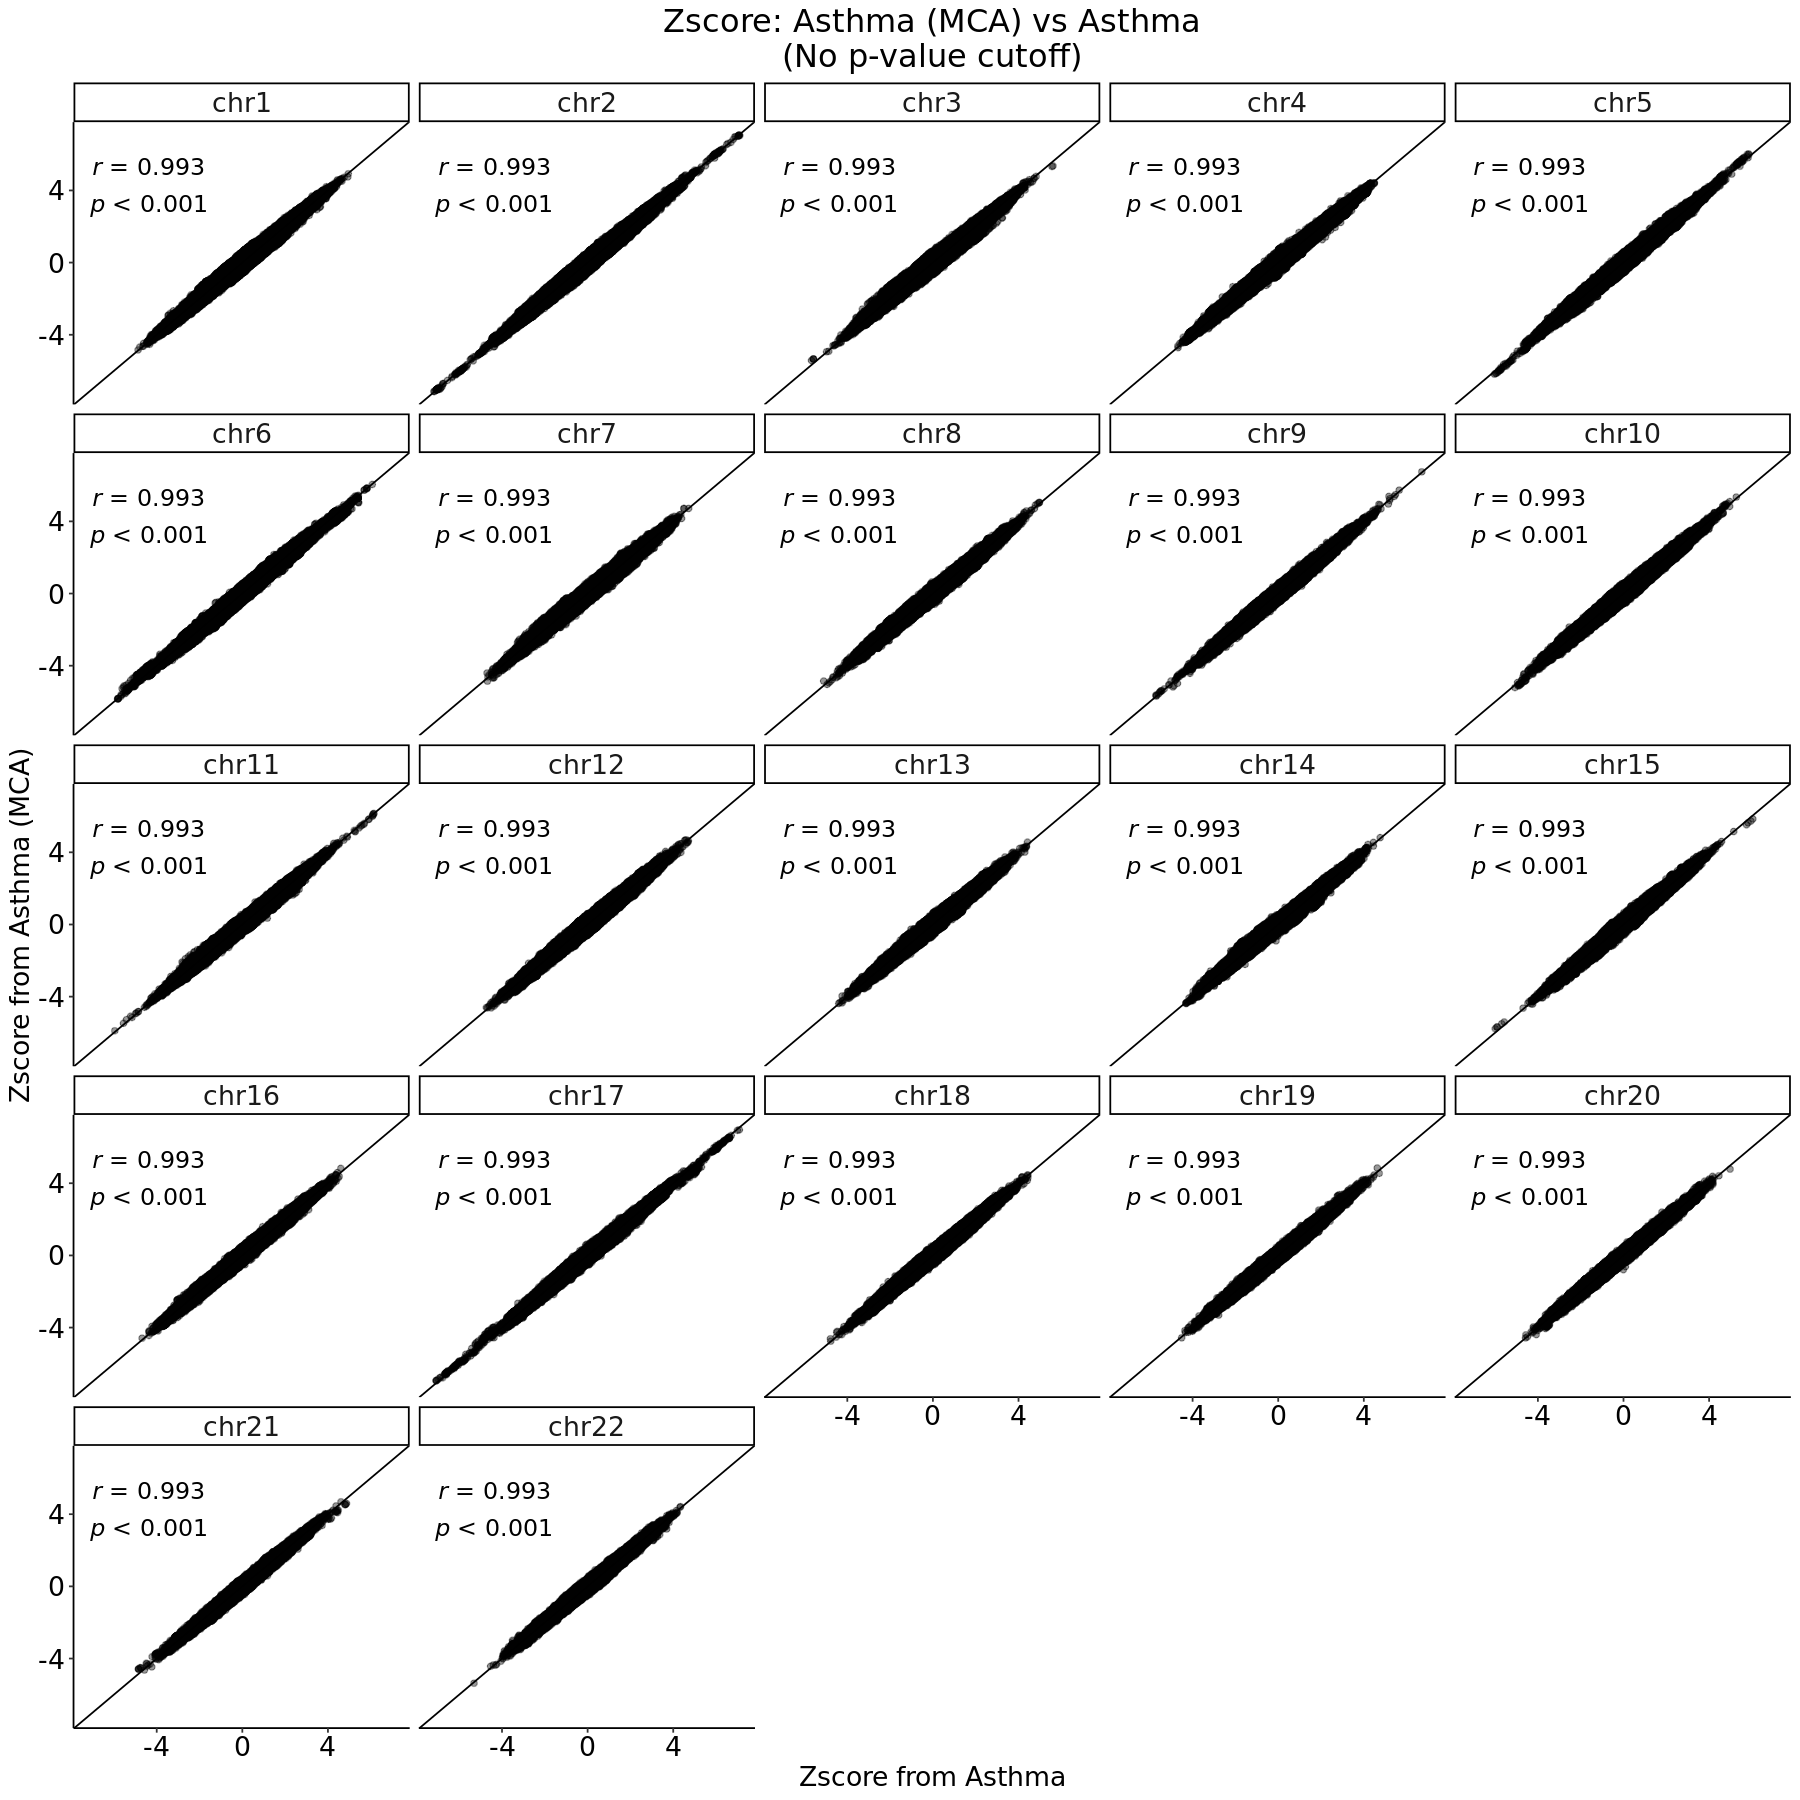

In [9]:
options(repr.plot.width = 15, repr.plot.height = 15)

# 1.df, 2.SNP, 3.position, 4.effect_allele, 5.other_allele, 6.beta, 7.sd, 8.z-score, 9.p-value, 10.is p log?, 11.name

p_asthma <- gwas_compare_plot(
    list(asthma, NULL, NULL, "Allele1", "Allele2", "Effect", "StdErr", NULL, "P-value", FALSE, "Asthma"),
    list(asthma_mca, NULL, NULL, "Allele1", "Allele2", "Effect", "StdErr", NULL, "P-value", FALSE, "Asthma (MCA)"),
    cutoff = 0
)
p_asthma

In [10]:
ggsave(
    paste0(fig.folder, "/zscore_asthma.tiff"),
    plot = p_asthma,
    device = "tiff",
    compression = 'lzw',
    bg = "white",
    dpi = 300,
    width = 15,
    height = 15,
    units = "in"
)

In [11]:
merged <- merge_gwas_sumstats(
    df1 = asthma, # First dataframe and its columns
    chr1 = NULL,
    snp1 = NULL,
    effect_allele1 = "Allele1",
    other_allele1 = "Allele2",
    beta1 = "Effect",
    se1 = "StdErr",
    z1 = NULL,
    p_log1 = c("P-value", FALSE), # (p-value column, is log?)
    suffix1 = "normal",
    df2 = asthma_mca, # Second dataframe and its columns
    chr2 = NULL,
    snp2 = NULL,
    effect_allele2 = "Allele1",
    other_allele2 = "Allele2",
    beta2 = "Effect",
    se2 = "StdErr",
    z2 = NULL,
    p_log2 = c("P-value", FALSE), # (p-value column, is log?)
    suffix2 = "mca"
)

head(merged)

cor.test(merged$z_normal, merged$z_mca, method = "pearson")

chr,snp,effect_allele,other_allele,z_normal,z_mca
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
chr1,chr1:100000223:C:T,T,C,-0.8070399,-0.7179061
chr1,chr1:10000044:A:T,A,T,-0.5369128,-0.3300000
chr1,chr1:100000723:G:A,A,G,-0.1294964,-0.2357143
chr1,chr1:100000829:T:C,T,C,-0.9628064,-0.8298231
chr1,chr1:100000839:T:A,A,T,0.1662708,0.2676056
chr1,chr1:100000874:G:GT,G,GT,-0.5049505,-0.3774510



	Pearson's product-moment correlation

data:  merged$z_normal and merged$z_mca
t = 41950, df = 25566116, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9928087 0.9928198
sample estimates:
      cor 
0.9928143 


In [12]:
rm(asthma)
rm(asthma_mca)
rm(p_asthma)

# CKD

In [ ]:
ckd <- fread_gcs_tsv("gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/ckd/gwas_meta1.tsv")

dim(ckd)
head(ckd)

In [ ]:
ckd_mca <- fread_gcs_tsv("gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/ckd_mca/gwas_meta1.tsv")

dim(ckd_mca)
head(ckd_mca)

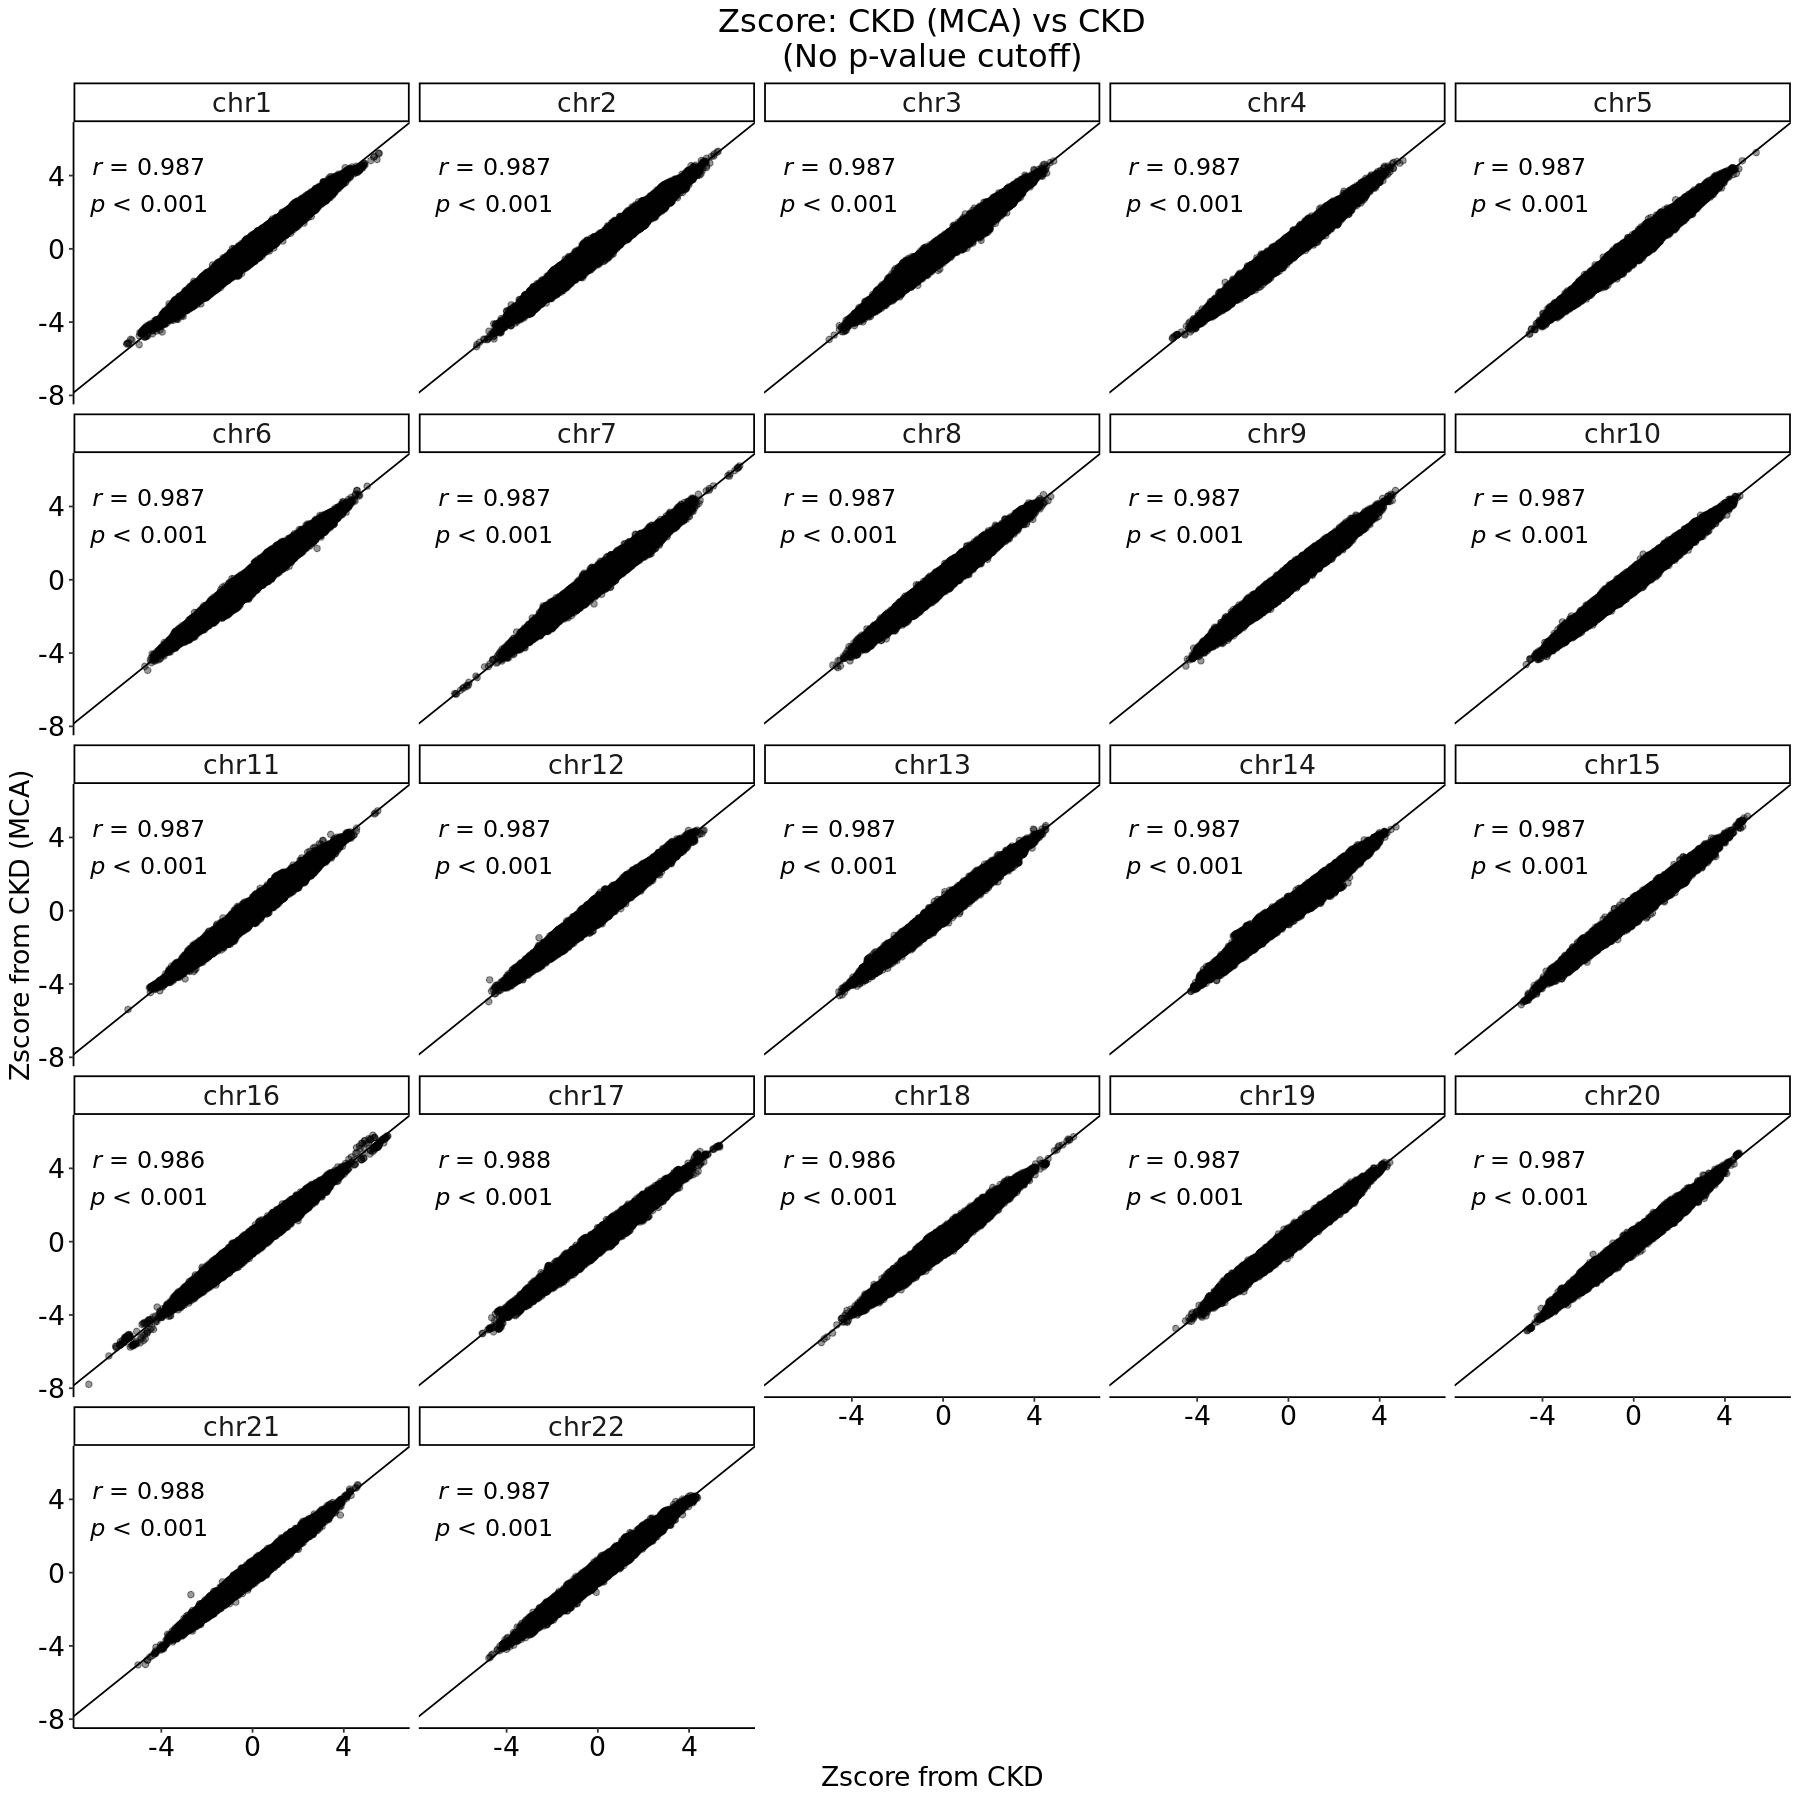

In [15]:
options(repr.plot.width = 15, repr.plot.height = 15)

# 1.df, 2.SNP, 3.position, 4.effect_allele, 5.other_allele, 6.beta, 7.sd, 8.z-score, 9.p-value, 10.is p log?, 11.name

p_ckd <- gwas_compare_plot(
    list(ckd, NULL, NULL, "Allele1", "Allele2", "Effect", "StdErr", NULL, "P-value", FALSE, "CKD"),
    list(ckd_mca, NULL, NULL, "Allele1", "Allele2", "Effect", "StdErr", NULL, "P-value", FALSE, "CKD (MCA)"),
    cutoff = 0
)
p_ckd

In [16]:
ggsave(
    paste0(fig.folder, "/zscore_ckd.tiff"),
    plot = p_ckd,
    device = "tiff",
    compression = 'lzw',
    bg = "white",
    dpi = 300,
    width = 15,
    height = 15,
    units = "in"
)

In [17]:
merged <- merge_gwas_sumstats(
    df1 = ckd, # First dataframe and its columns
    chr1 = NULL,
    snp1 = NULL,
    effect_allele1 = "Allele1",
    other_allele1 = "Allele2",
    beta1 = "Effect",
    se1 = "StdErr",
    z1 = NULL,
    p_log1 = c("P-value", FALSE), # (p-value column, is log?)
    suffix1 = "normal",
    df2 = ckd_mca, # Second dataframe and its columns
    chr2 = NULL,
    snp2 = NULL,
    effect_allele2 = "Allele1",
    other_allele2 = "Allele2",
    beta2 = "Effect",
    se2 = "StdErr",
    z2 = NULL,
    p_log2 = c("P-value", FALSE), # (p-value column, is log?)
    suffix2 = "mca"
)

head(merged)

cor.test(merged$z_normal, merged$z_mca, method = "pearson")

chr,snp,effect_allele,other_allele,z_normal,z_mca
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
chr1,chr1:100000223:C:T,T,C,1.0057205,1.1584544
chr1,chr1:10000044:A:T,A,T,-1.1302083,-0.8730964
chr1,chr1:100000723:G:A,A,G,-1.2240437,-1.4270270
chr1,chr1:100000829:T:C,T,C,0.6060403,0.3547120
chr1,chr1:100000839:T:A,A,T,-0.2619469,-0.2670157
chr1,chr1:100000874:G:GT,G,GT,0.4097744,0.4758364



	Pearson's product-moment correlation

data:  merged$z_normal and merged$z_mca
t = 30908, df = 25566116, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9868717 0.9868919
sample estimates:
      cor 
0.9868818 


In [18]:
rm(ckd)
rm(ckd_mca)
rm(p_ckd)

# Coronary heart disease

In [ ]:
coronary_heart_disease <- fread_gcs_tsv("gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/coronary_heart_disease/gwas_meta1.tsv")

dim(coronary_heart_disease)
head(coronary_heart_disease)

In [ ]:
coronary_heart_disease_mca <- fread_gcs_tsv("gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/coronary_heart_disease_mca/gwas_meta1.tsv")

dim(coronary_heart_disease_mca)
head(coronary_heart_disease_mca)

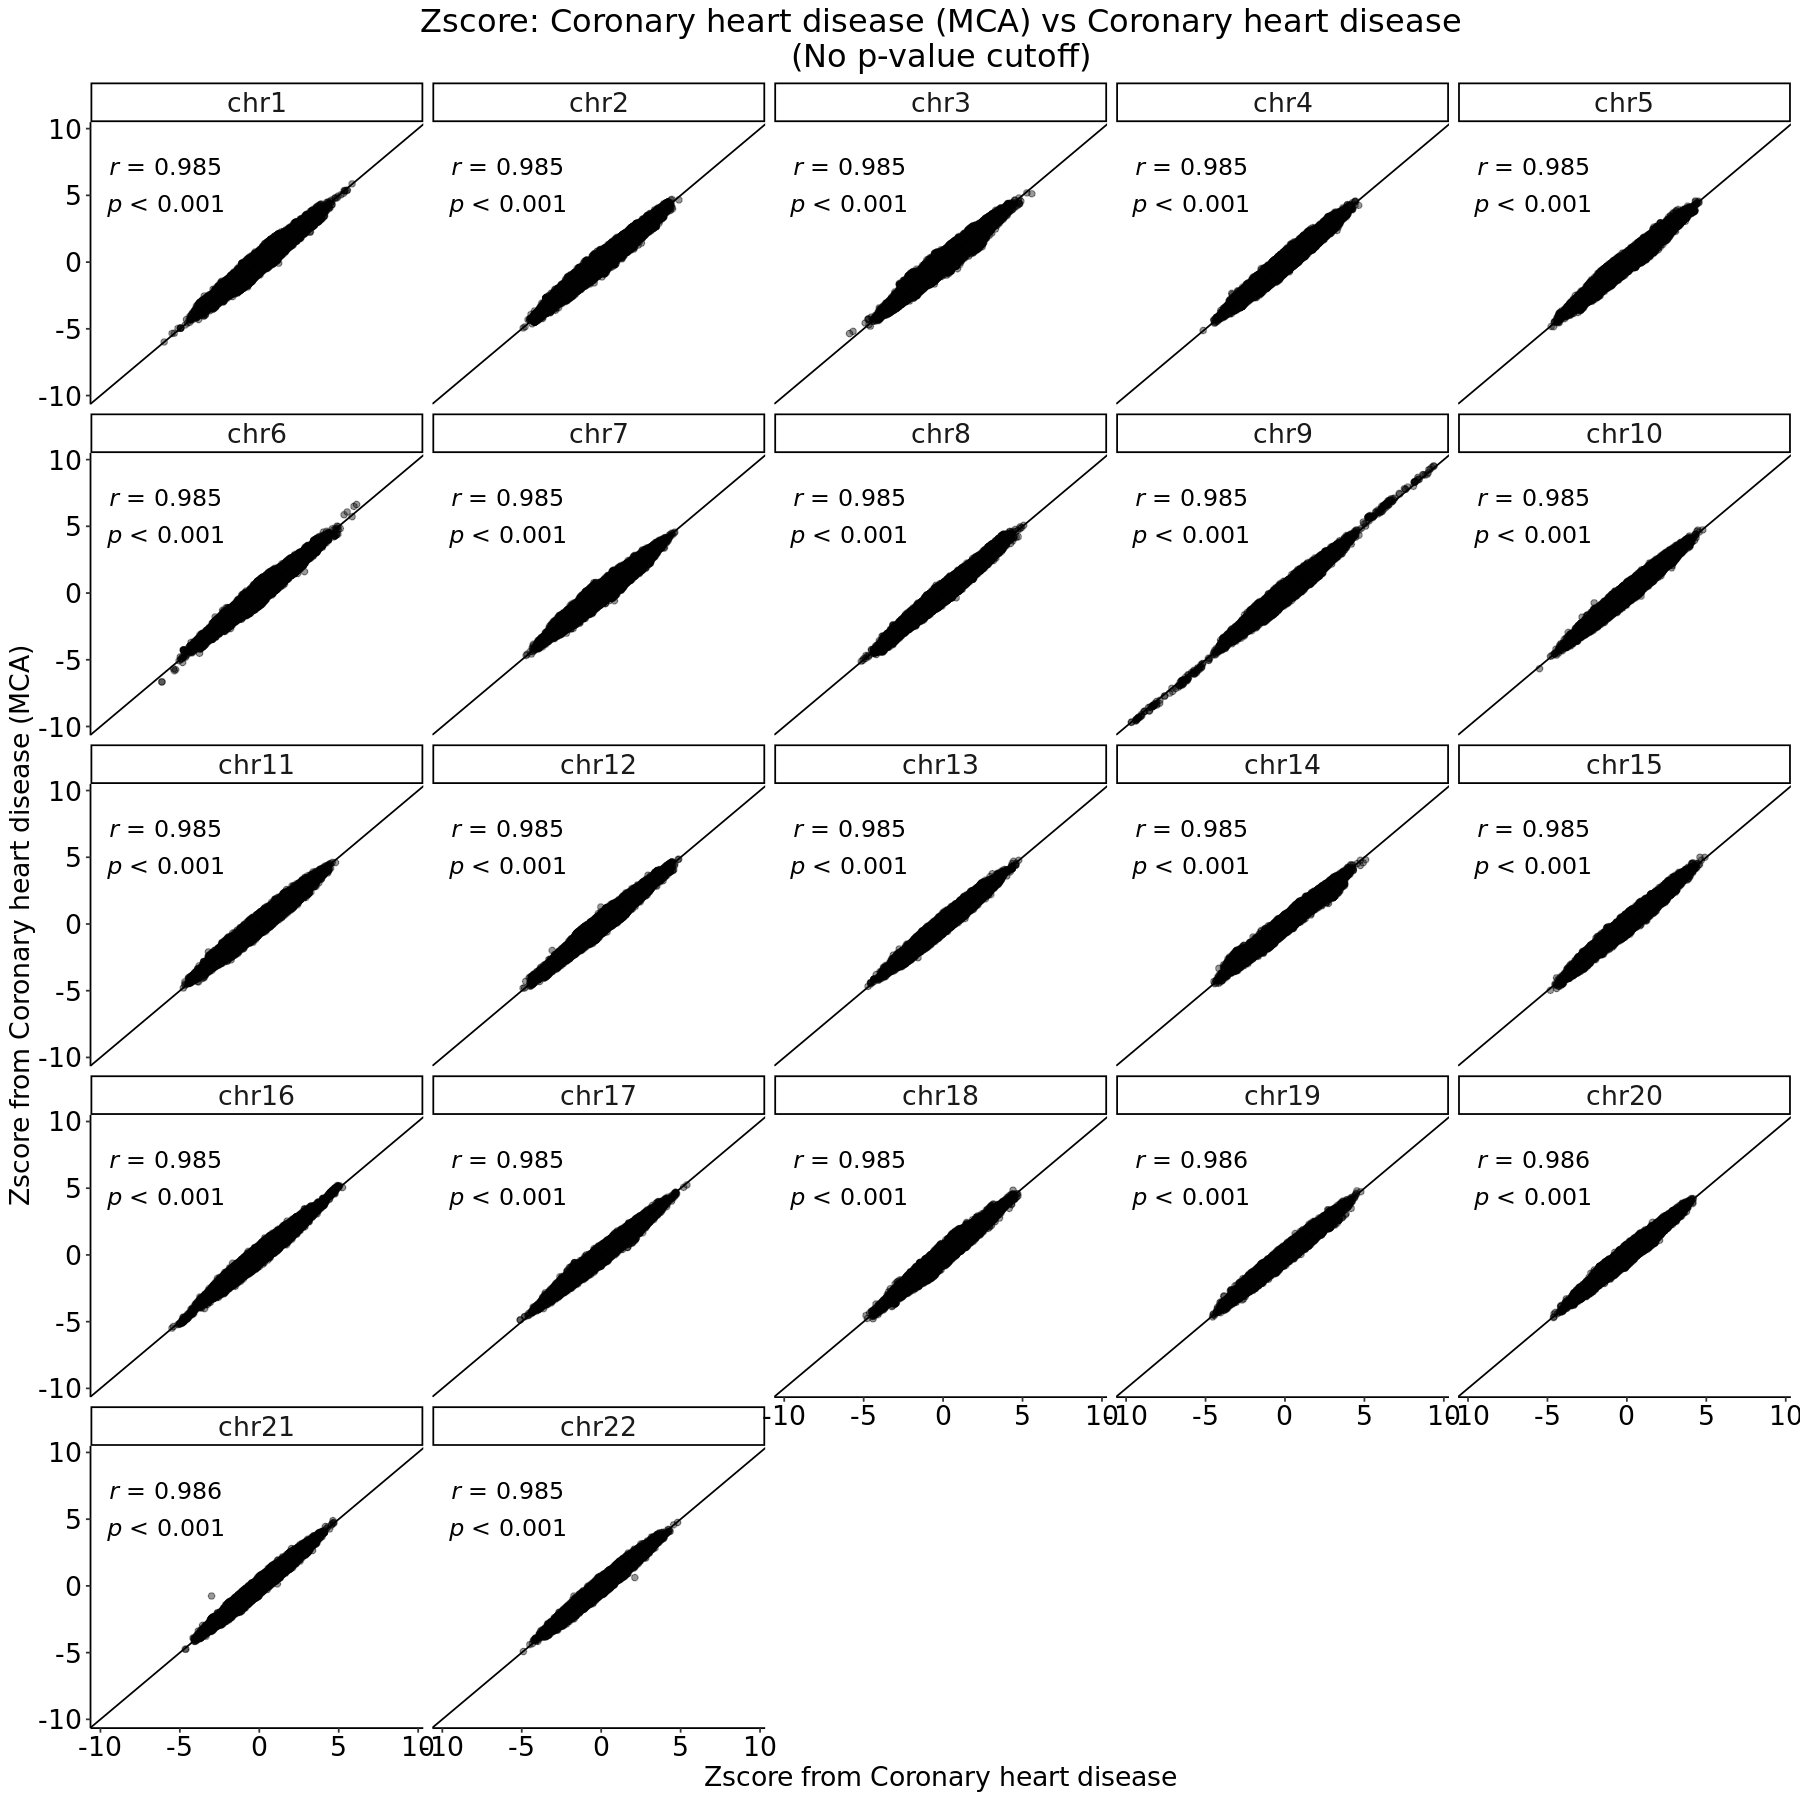

In [21]:
options(repr.plot.width = 15, repr.plot.height = 15)

# 1.df, 2.SNP, 3.position, 4.effect_allele, 5.other_allele, 6.beta, 7.sd, 8.z-score, 9.p-value, 10.is p log?, 11.name

p_chd <- gwas_compare_plot(
    list(coronary_heart_disease, NULL, NULL, "Allele1", "Allele2", "Effect", "StdErr", NULL, "P-value", FALSE, "Coronary heart disease"),
    list(coronary_heart_disease_mca, NULL, NULL, "Allele1", "Allele2", "Effect", "StdErr", NULL, "P-value", FALSE, "Coronary heart disease (MCA)"),
    cutoff = 0
)
p_chd

In [22]:
ggsave(
    paste0(fig.folder, "/zscore_chd.tiff"),
    plot = p_chd,
    device = "tiff",
    compression = 'lzw',
    bg = "white",
    dpi = 300,
    width = 15,
    height = 15,
    units = "in"
)

In [23]:
merged <- merge_gwas_sumstats(
    df1 = coronary_heart_disease, # First dataframe and its columns
    chr1 = NULL,
    snp1 = NULL,
    effect_allele1 = "Allele1",
    other_allele1 = "Allele2",
    beta1 = "Effect",
    se1 = "StdErr",
    z1 = NULL,
    p_log1 = c("P-value", FALSE), # (p-value column, is log?)
    suffix1 = "normal",
    df2 = coronary_heart_disease_mca, # Second dataframe and its columns
    chr2 = NULL,
    snp2 = NULL,
    effect_allele2 = "Allele1",
    other_allele2 = "Allele2",
    beta2 = "Effect",
    se2 = "StdErr",
    z2 = NULL,
    p_log2 = c("P-value", FALSE), # (p-value column, is log?)
    suffix2 = "mca"
)

head(merged)

cor.test(merged$z_normal, merged$z_mca, method = "pearson")

chr,snp,effect_allele,other_allele,z_normal,z_mca
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
chr1,chr1:100000223:C:T,T,C,0.7872676,0.8067098
chr1,chr1:10000044:A:T,A,T,-0.4676471,-0.3391304
chr1,chr1:100000723:G:A,A,G,0.1172840,-0.2606061
chr1,chr1:100000829:T:C,T,C,-1.4220056,-1.6098563
chr1,chr1:100000839:T:A,A,T,1.8518519,1.8707071
chr1,chr1:100000874:G:GT,G,GT,-0.7319149,-0.7196653



	Pearson's product-moment correlation

data:  merged$z_normal and merged$z_mca
t = 28846, df = 25566116, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9849710 0.9849941
sample estimates:
      cor 
0.9849825 


In [24]:
rm(coronary_heart_disease)
rm(coronary_heart_disease_mca)
rm(p_chd)

# Hypercholesterolemia

In [ ]:
hypercholesterolemia <- fread_gcs_tsv("gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/hypercholesterolemia/gwas_meta1.tsv")

dim(hypercholesterolemia)
head(hypercholesterolemia)

In [ ]:
hypercholesterolemia_mca <- fread_gcs_tsv("gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/hypercholesterolemia_mca/gwas_meta1.tsv")

dim(hypercholesterolemia_mca)
head(hypercholesterolemia_mca)

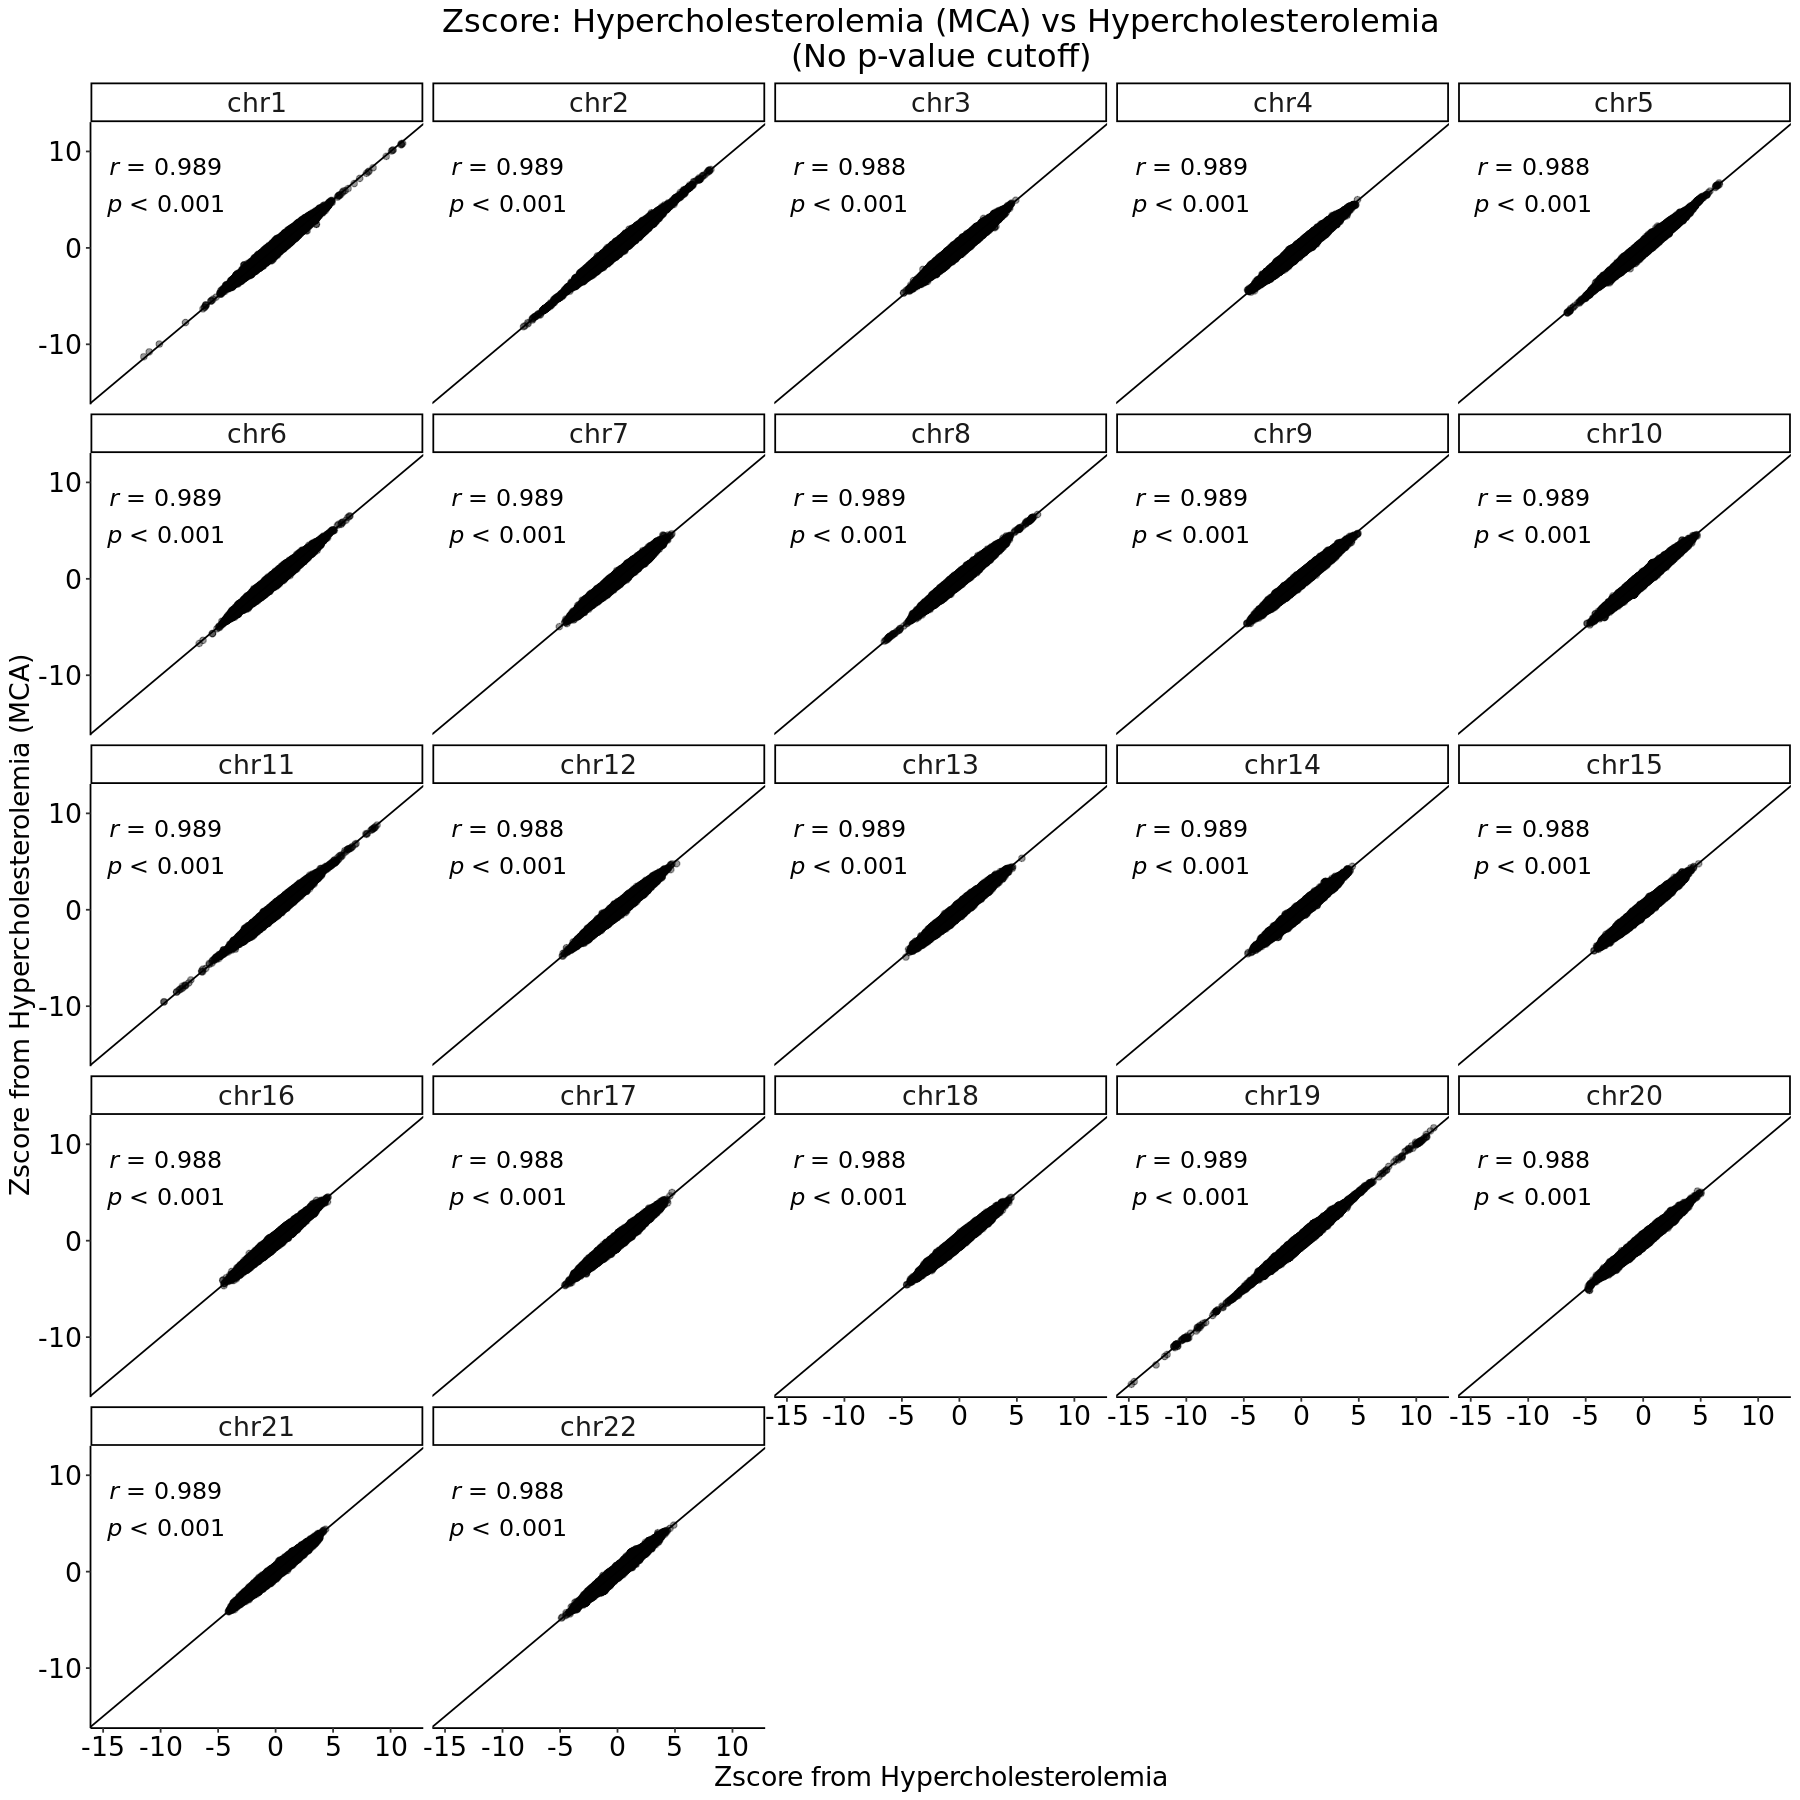

In [27]:
options(repr.plot.width = 15, repr.plot.height = 15)

# 1.df, 2.SNP, 3.position, 4.effect_allele, 5.other_allele, 6.beta, 7.sd, 8.z-score, 9.p-value, 10.is p log?, 11.name

p_hypercholesterolemia <- gwas_compare_plot(
    list(hypercholesterolemia, NULL, NULL, "Allele1", "Allele2", "Effect", "StdErr", NULL, "P-value", FALSE, "Hypercholesterolemia"),
    list(hypercholesterolemia_mca, NULL, NULL, "Allele1", "Allele2", "Effect", "StdErr", NULL, "P-value", FALSE, "Hypercholesterolemia (MCA)"),
    cutoff = 0
)
p_hypercholesterolemia

In [28]:
ggsave(
    paste0(fig.folder, "/zscore_hypercholesterolemia.tiff"),
    plot = p_hypercholesterolemia,
    device = "tiff",
    compression = 'lzw',
    bg = "white",
    dpi = 300,
    width = 15,
    height = 15,
    units = "in"
)

In [29]:
merged <- merge_gwas_sumstats(
    df1 = hypercholesterolemia, # First dataframe and its columns
    chr1 = NULL,
    snp1 = NULL,
    effect_allele1 = "Allele1",
    other_allele1 = "Allele2",
    beta1 = "Effect",
    se1 = "StdErr",
    z1 = NULL,
    p_log1 = c("P-value", FALSE), # (p-value column, is log?)
    suffix1 = "normal",
    df2 = hypercholesterolemia_mca, # Second dataframe and its columns
    chr2 = NULL,
    snp2 = NULL,
    effect_allele2 = "Allele1",
    other_allele2 = "Allele2",
    beta2 = "Effect",
    se2 = "StdErr",
    z2 = NULL,
    p_log2 = c("P-value", FALSE), # (p-value column, is log?)
    suffix2 = "mca"
)

head(merged)

cor.test(merged$z_normal, merged$z_mca, method = "pearson")

chr,snp,effect_allele,other_allele,z_normal,z_mca
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
chr1,chr1:100000223:C:T,T,C,0.27490040,0.28177864
chr1,chr1:10000044:A:T,A,T,0.34154930,0.36363636
chr1,chr1:100000723:G:A,A,G,-2.23357664,-2.17391304
chr1,chr1:100000829:T:C,T,C,0.51266309,0.15225425
chr1,chr1:100000839:T:A,A,T,0.06265664,0.05721393
chr1,chr1:100000874:G:GT,G,GT,-1.47979798,-1.38000000



	Pearson's product-moment correlation

data:  merged$z_normal and merged$z_mca
t = 33287, df = 25566116, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9886505 0.9886679
sample estimates:
      cor 
0.9886592 


In [30]:
rm(hypercholesterolemia)
rm(hypercholesterolemia_mca)
rm(p_hypercholesterolemia)

# Breast cancer

In [ ]:
breast_cancer <- fread_gcs_tsv("gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/breast_cancer/gwas_meta1.tsv")

dim(breast_cancer)
head(breast_cancer)

In [ ]:
breast_cancer_mca <- fread_gcs_tsv("gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/breast_cancer_mca/gwas_meta1.tsv")

dim(breast_cancer_mca)
head(breast_cancer_mca)

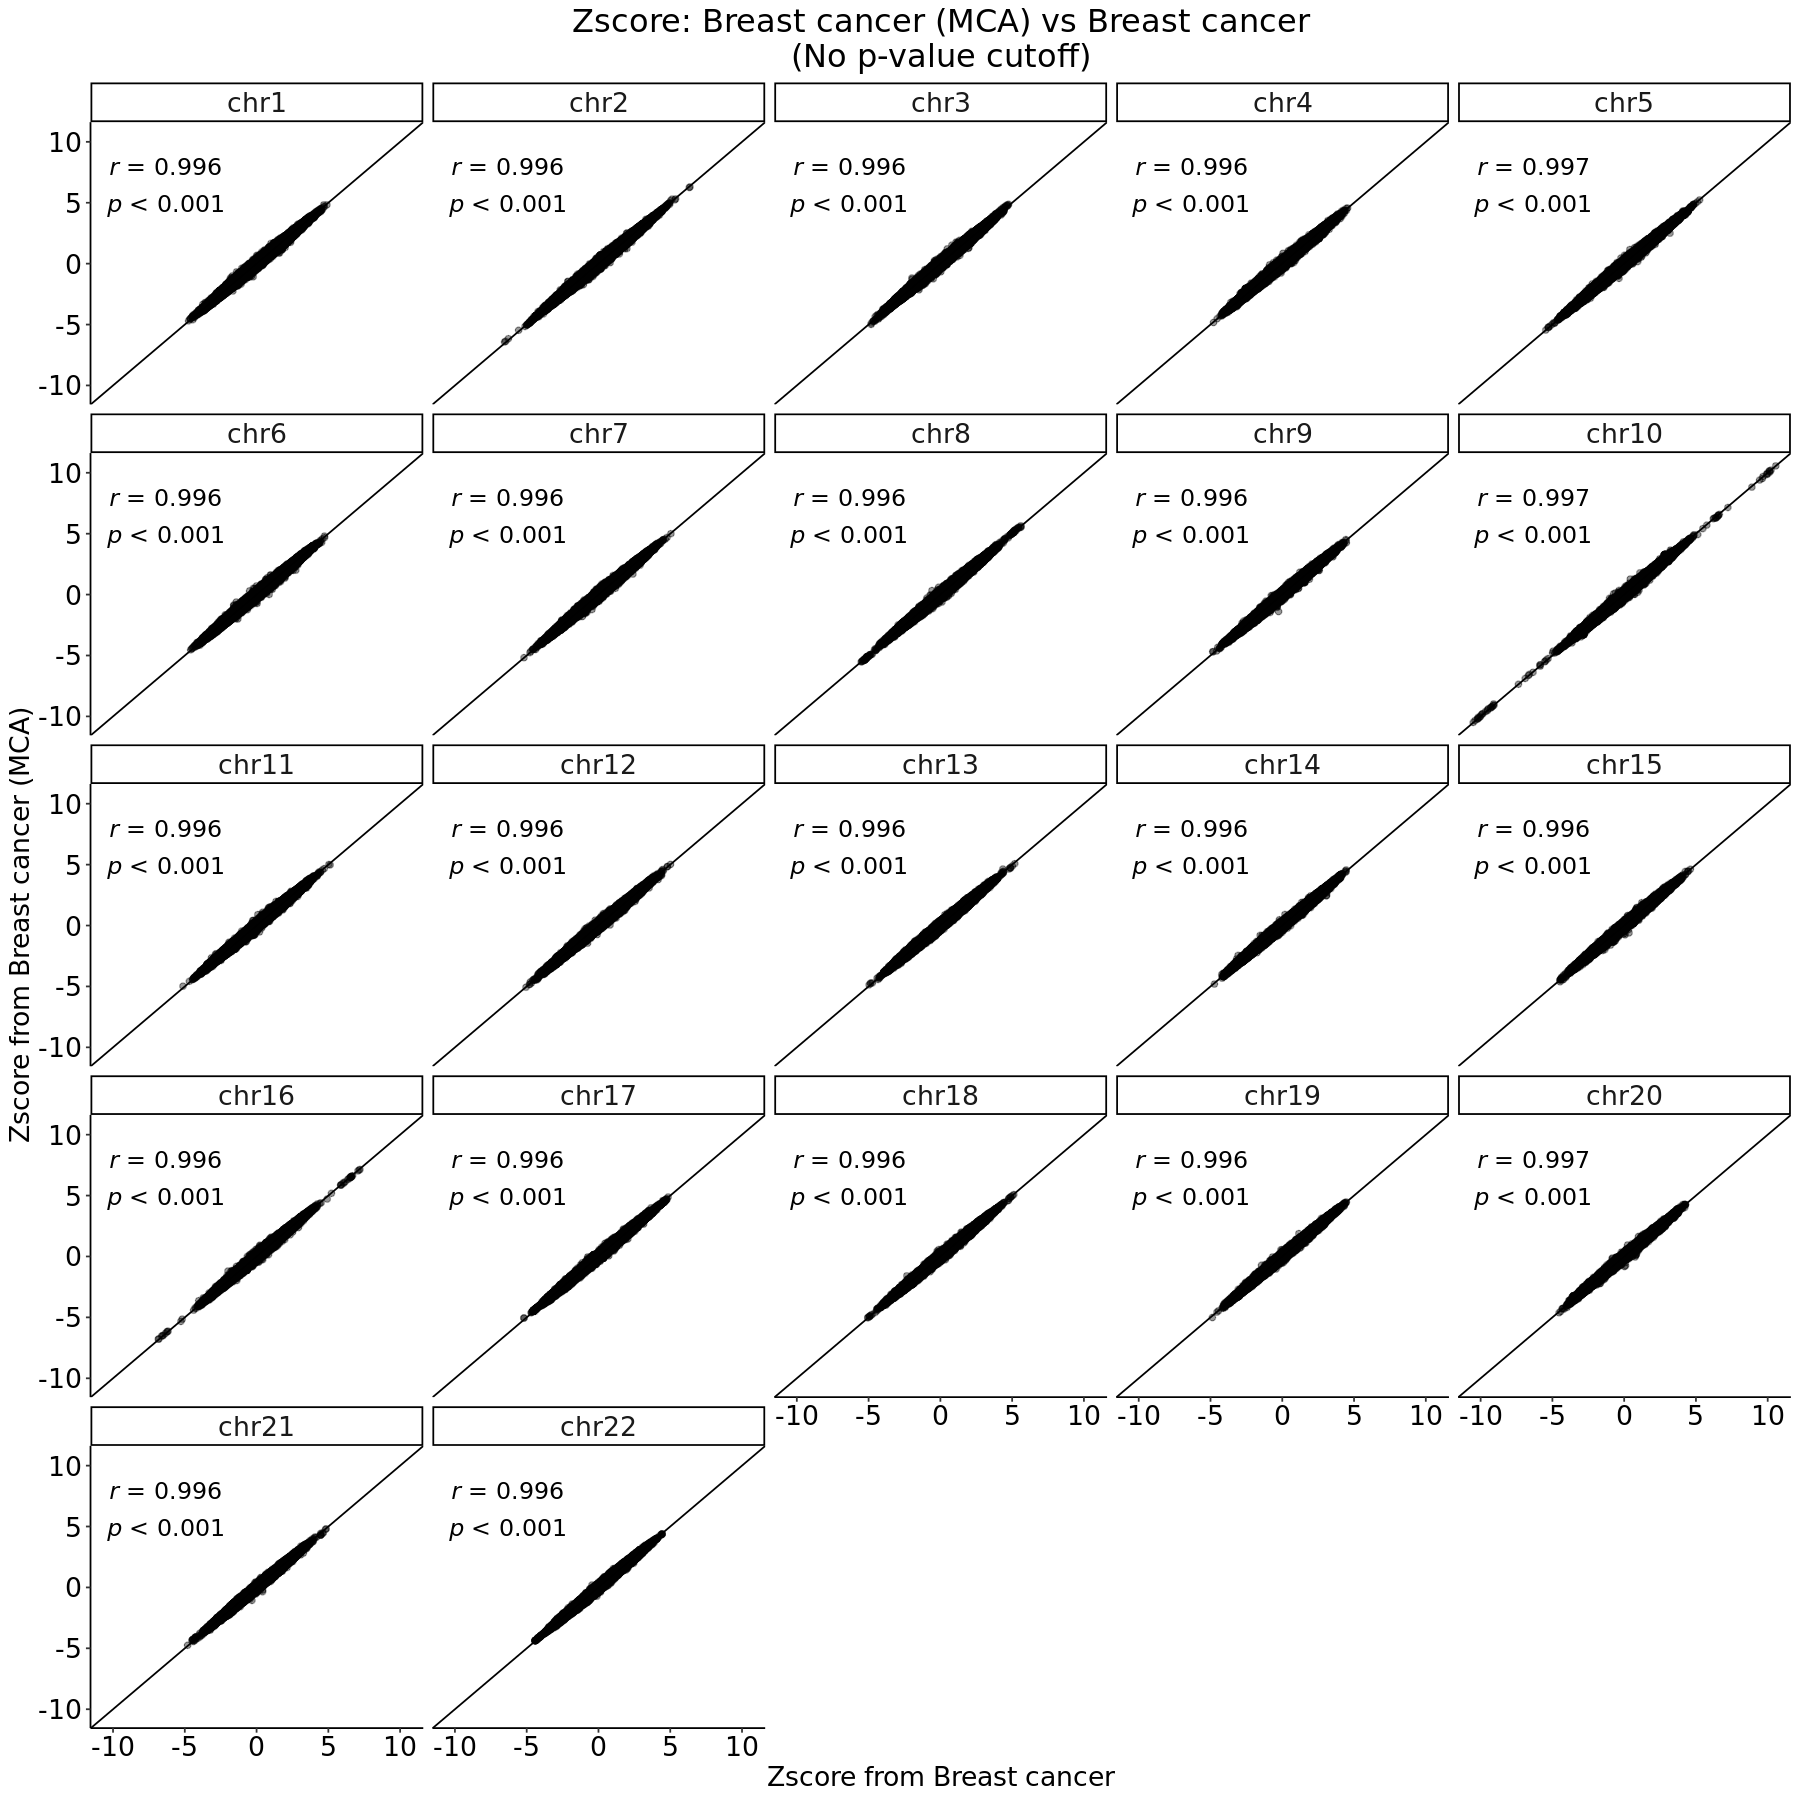

In [33]:
options(repr.plot.width = 15, repr.plot.height = 15)

# 1.df, 2.SNP, 3.position, 4.effect_allele, 5.other_allele, 6.beta, 7.sd, 8.z-score, 9.p-value, 10.is p log?, 11.name

p_breast_cancer <- gwas_compare_plot(
    list(breast_cancer, NULL, NULL, "Allele1", "Allele2", "Effect", "StdErr", NULL, "P-value", FALSE, "Breast cancer"),
    list(breast_cancer_mca, NULL, NULL, "Allele1", "Allele2", "Effect", "StdErr", NULL, "P-value", FALSE, "Breast cancer (MCA)"),
    cutoff = 0
)
p_breast_cancer

In [34]:
ggsave(
    paste0(fig.folder, "/zscore_breast_cancer.tiff"),
    plot = p_breast_cancer,
    device = "tiff",
    compression = 'lzw',
    bg = "white",
    dpi = 300,
    width = 15,
    height = 15,
    units = "in"
)

In [35]:
merged <- merge_gwas_sumstats(
    df1 = breast_cancer, # First dataframe and its columns
    chr1 = NULL,
    snp1 = NULL,
    effect_allele1 = "Allele1",
    other_allele1 = "Allele2",
    beta1 = "Effect",
    se1 = "StdErr",
    z1 = NULL,
    p_log1 = c("P-value", FALSE), # (p-value column, is log?)
    suffix1 = "normal",
    df2 = breast_cancer_mca, # Second dataframe and its columns
    chr2 = NULL,
    snp2 = NULL,
    effect_allele2 = "Allele1",
    other_allele2 = "Allele2",
    beta2 = "Effect",
    se2 = "StdErr",
    z2 = NULL,
    p_log2 = c("P-value", FALSE), # (p-value column, is log?)
    suffix2 = "mca"
)

head(merged)

cor.test(merged$z_normal, merged$z_mca, method = "pearson")

chr,snp,effect_allele,other_allele,z_normal,z_mca
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
chr1,chr1:10000044:A:T,A,T,-0.4504065,-0.5870968
chr1,chr1:100000723:G:A,A,G,1.3511706,1.4651163
chr1,chr1:100000829:T:C,T,C,-0.6726698,-0.6860720
chr1,chr1:100000839:T:A,A,T,0.6744731,0.7066356
chr1,chr1:100000874:G:GT,G,GT,1.6997743,1.6278027
chr1,chr1:10000113:C:T,T,C,-2.8707403,-2.7986030



	Pearson's product-moment correlation

data:  merged$z_normal and merged$z_mca
t = 58804, df = 25039799, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9963961 0.9964017
sample estimates:
      cor 
0.9963989 


In [36]:
rm(breast_cancer)
rm(breast_cancer_mca)
rm(p_breast_cancer)

# Prostate cancer

In [ ]:
prostate_cancer <- fread_gcs_tsv("gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/prostate_cancer/gwas_meta1.tsv")

dim(prostate_cancer)
head(prostate_cancer)

In [ ]:
prostate_cancer_mca <- fread_gcs_tsv("gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/prostate_cancer_mca/gwas_meta1.tsv")

dim(prostate_cancer_mca)
head(prostate_cancer_mca)

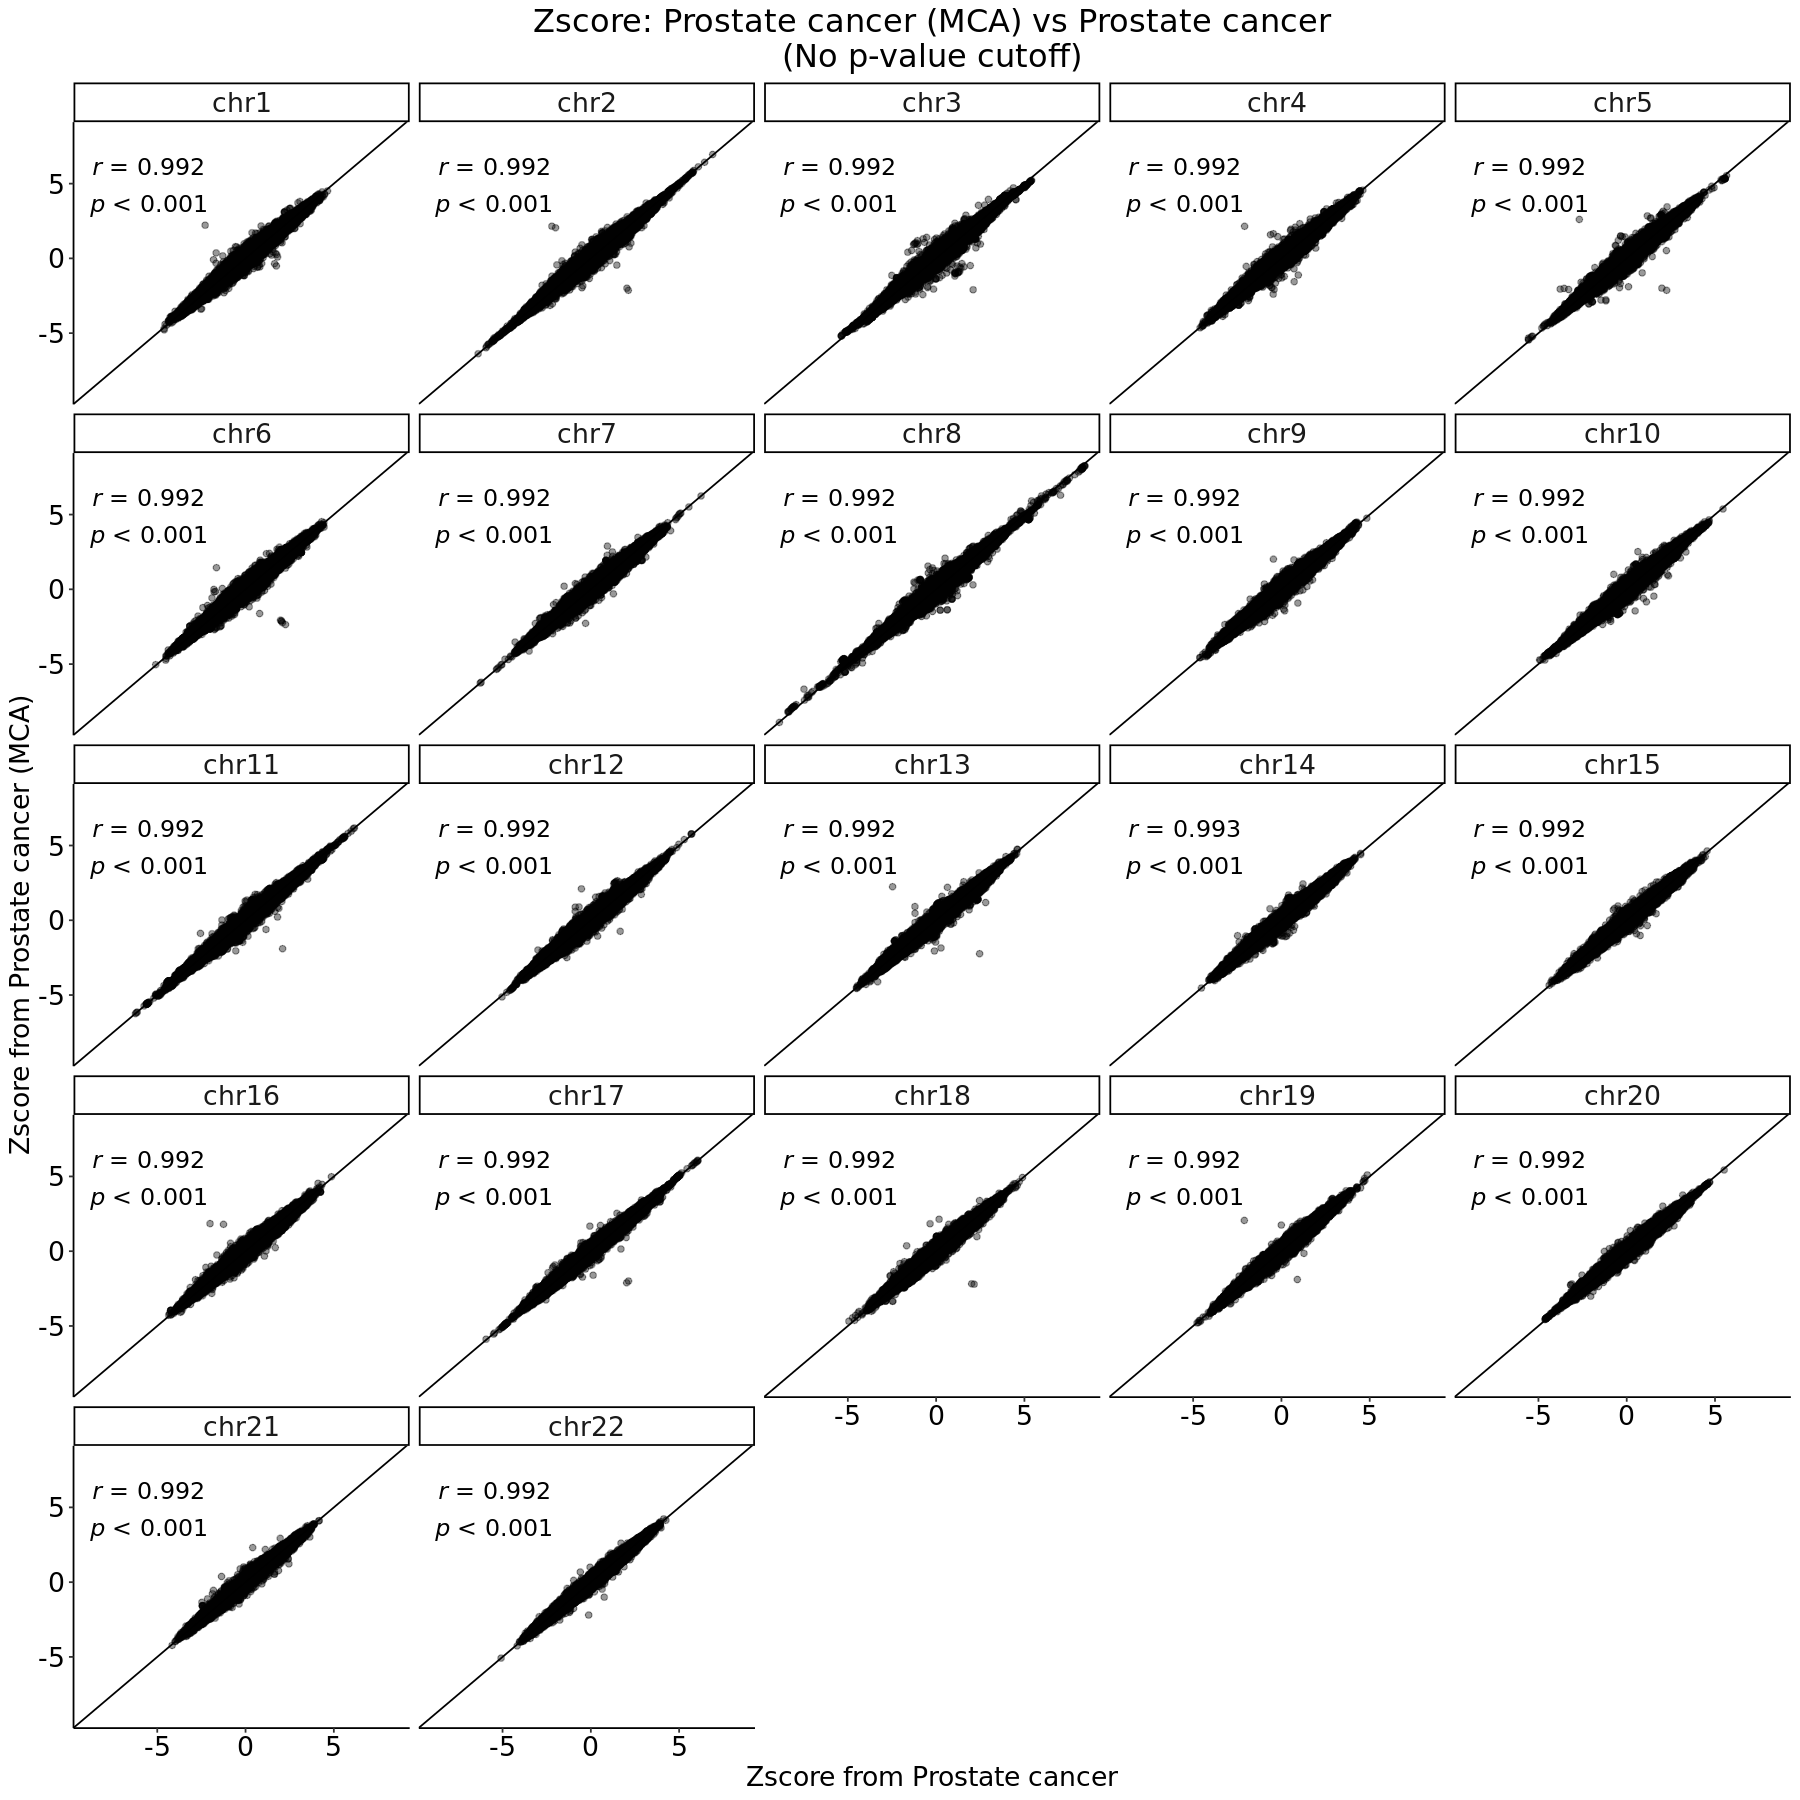

In [39]:
options(repr.plot.width = 15, repr.plot.height = 15)

# 1.df, 2.SNP, 3.position, 4.effect_allele, 5.other_allele, 6.beta, 7.sd, 8.z-score, 9.p-value, 10.is p log?, 11.name

p_prostate_cancer <- gwas_compare_plot(
    list(prostate_cancer, NULL, NULL, "Allele1", "Allele2", "Effect", "StdErr", NULL, "P-value", FALSE, "Prostate cancer"),
    list(prostate_cancer_mca, NULL, NULL, "Allele1", "Allele2", "Effect", "StdErr", NULL, "P-value", FALSE, "Prostate cancer (MCA)"),
    cutoff = 0
)
p_prostate_cancer

In [40]:
ggsave(
    paste0(fig.folder, "/zscore_prostate_cancer.tiff"),
    plot = p_prostate_cancer,
    device = "tiff",
    compression = 'lzw',
    bg = "white",
    dpi = 300,
    width = 15,
    height = 15,
    units = "in"
)

In [41]:
merged <- merge_gwas_sumstats(
    df1 = prostate_cancer, # First dataframe and its columns
    chr1 = NULL,
    snp1 = NULL,
    effect_allele1 = "Allele1",
    other_allele1 = "Allele2",
    beta1 = "Effect",
    se1 = "StdErr",
    z1 = NULL,
    p_log1 = c("P-value", FALSE), # (p-value column, is log?)
    suffix1 = "normal",
    df2 = prostate_cancer_mca, # Second dataframe and its columns
    chr2 = NULL,
    snp2 = NULL,
    effect_allele2 = "Allele1",
    other_allele2 = "Allele2",
    beta2 = "Effect",
    se2 = "StdErr",
    z2 = NULL,
    p_log2 = c("P-value", FALSE), # (p-value column, is log?)
    suffix2 = "mca"
)

head(merged)

cor.test(merged$z_normal, merged$z_mca, method = "pearson")

chr,snp,effect_allele,other_allele,z_normal,z_mca
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
chr1,chr1:10000044:A:T,A,T,2.8229548,2.842615012
chr1,chr1:100000723:G:A,A,G,-1.2868421,-1.106770833
chr1,chr1:100000839:T:A,A,T,0.6920385,0.665796345
chr1,chr1:100000874:G:GT,G,GT,-0.1259124,0.003623188
chr1,chr1:10000113:C:T,T,C,-0.5297561,-0.367076632
chr1,chr1:100001223:T:A,A,T,1.7907422,1.641530883



	Pearson's product-moment correlation

data:  merged$z_normal and merged$z_mca
t = 38315, df = 22940626, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9922709 0.9922835
sample estimates:
      cor 
0.9922772 


In [42]:
rm(prostate_cancer)
rm(prostate_cancer_mca)
rm(p_prostate_cancer)

# Compare peaks only

In [25]:
merge_disease <- function(
    gcp_path
){
    
    all_df <- fread_gcs_tsv(gcp_path, header = TRUE) %>%
        flip_alleles_by_freq()
    
    merged_df <- rbind(
    merge(all_df %>%
              filter(mca == FALSE),
          all_df %>%
              filter(mca == TRUE),
          by = c("MarkerName", "Allele1", "Allele2")),
    merge(all_df %>%
              filter(mca == FALSE),
          all_df %>%
              filter(mca == TRUE) %>%
              rename(Allele1 = "Allele2", Allele2 = "Allele1") %>%
              mutate(Effect = -Effect, Freq1 = 1-Freq1),
          by = c("MarkerName", "Allele1", "Allele2"))
    ) %>%
    na.omit() %>%
    mutate(b_label = case_when(
        p_value.x < 5e-8 & p_value.y < 5e-8 ~ "in both",
        p_value.x >= 5e-8 & p_value.y < 5e-8 ~ "with MCA",
        p_value.x < 5e-8 & p_value.y >= 5e-8 ~ "without MCA",
        p_value.x >= 5e-8 & p_value.y >= 5e-8 ~ NA,
    )) %>%
    na.omit()
    
    
    merged_df <- merged_df[!duplicated(merged_df),] %>%
        mutate(b_color = case_when(
            b_label == "in both" ~ "#F8766D",
            b_label == "with MCA" ~ "#00BA38",
            b_label == "without MCA" ~ "#619CFF",
            .default = NA,
        )) %>%
        group_by(b_label) %>%
        mutate(sig_count = length(unique(MarkerName))) %>%
        ungroup() %>%
        mutate(b_label = paste0(b_label, " (", sig_count, ")"))
    
    return(merged_df)
}

plot_disease_pbeta <- function(
    disease,
    pt_title
){

    merged_df <- merge_disease(
        paste0(
            "gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/peaks/details_",
            disease,
            ".tsv"
        )
    )
    
    cat(paste0(pt_title, " :", cor.test(merged_df$Effect.x, merged_df$Effect.y, method = "pearson")$p.value, "\n"))

    p_p <- ggplot(merged_df,
           aes(x = -log10(p_value.x), y = -log10(p_value.y))) +
        geom_abline(slope=1, intercept = 0)+
        xlab(expression("-log"["10"] ~ "p (without MCA)"))+
        ylab(expression("-log"["10"] ~ "p (with MCA)"))+
        geom_vline(xintercept = -log10(5*10^(-8)), linetype="dashed", color = "red")+
        geom_hline(yintercept = -log10(5*10^(-8)), linetype="dashed", color = "red")+
        geom_point(size = 2, color = "black", pch=21, aes(fill = b_label))+
        #scale_fill_manual(values = setNames(c("#F8766D","#00BA38","#619CFF"), c("Both","With MCA","Without MCA")))+
        scale_fill_manual(values = setNames(merged_df$b_color, merged_df$b_label))+
        #ggtitle(paste0("p-value comparison for ", pt_title))+
        theme_bw()+
        theme(plot.title = element_text(hjust = 0.5, size = 10),
              legend.position = "none",
              axis.text = element_text(size = 10, colour = "black"),
              text = element_text(size = 10))

    p_b <- ggplot(merged_df,
           aes(x = Effect.x, y = Effect.y)) +
        geom_vline(xintercept = 0, linetype="dashed", color = "grey")+
        geom_hline(yintercept = 0, linetype="dashed", color = "grey")+
        geom_abline(slope=1, intercept = 0)+
        xlab("\u03B2 \u00B1 SE (without MCA)")+
        ylab("\u03B2 \u00B1 SE (with MCA)")+
        geom_errorbar(aes(ymin = Effect.y - StdErr.y, ymax = Effect.y + StdErr.y), width = 0.01)+
        geom_errorbar(aes(xmin = Effect.x - StdErr.x, xmax = Effect.x + StdErr.x), width = 0.01)+
        geom_point(size = 2, color = "black", pch=21, aes(fill = b_label))+
        #scale_fill_manual(values = setNames(c("#F8766D","#00BA38","#619CFF"), c("Both","With MCA","Without MCA")))+
        scale_fill_manual(values = setNames(merged_df$b_color, merged_df$b_label))+
        stat_cor(method = "pearson",
                 label.x.npc = "left",
                 label.y.npc = "top",
                 cor.coef.name = "r",
                 p.accuracy = 0.001,
                 r.accuracy = 0.001,
                 label.sep = "\n",
                 size = 3)+
        guides(fill = guide_legend("Significant"))+
        #ggtitle(paste0("Effect size comparison for ", pt_title))+
        theme_bw()+
        scale_x_continuous(labels = function(x) {
            x <- sub("\\.?0+$", "", x)
            ifelse(x == "", "0", x)
        }) +
        scale_y_continuous(labels = function(x) {
            x <- sub("\\.?0+$", "", x)
            ifelse(x == "", "0", x)
        }) +
        theme(plot.title = element_text(hjust = 0.5, size = 10),
              legend.position = "top",
              legend.title = element_text(margin = margin(r = 12)), # Adds air between title and labels
              legend.text = element_text(margin = margin(r = 12)),  # Adds air between legend items
              legend.key.width = unit(0.4, "cm"),     # shrink horizontal spacing
              #legend.key.height = unit(0.4, "cm"),    # shrink vertical spacing
              legend.spacing.x = unit(0.4, "cm"),     # space between items
              #legend.spacing.y = unit(0.1, "cm"),
              axis.text = element_text(size = 10, colour = "black"),
              text = element_text(size = 10))
    
    # Extract the legend safely
    guides_all <- cowplot::get_plot_component(p_b, "guide-box", return_all = TRUE)
    is_not_empty <- vapply(guides_all, function(x) !inherits(x, "zeroGrob"), logical(1))
    shared_legend <- guides_all[is_not_empty][[1]]
                           
    # Strip the legend out of p_b so the subplots have maximum room
    p_b <- p_b + theme(legend.position = "none")
                           
    W <- 24
    H <- 14                       
                           
    final_plot <- ggdraw() +
        draw_plot(
            shared_legend,
            x = 1 / W,
            y = 12.3 / H,
            width = 22 / W,
            height = 1.2 / H
        ) +
        draw_plot(p_p, x = 0 / W, y = 0 / H, width = 12 / W, height = 12 / H) + 
        draw_plot(p_b, x = 12 / W, y = 0 / H, width = 12 / W, height = 12 / H)

    final_grid <- annotate_figure(
        final_plot,
        top = text_grob(pt_title, size = 12, face = "bold")
    )

    return(final_grid)

}

Coronary heart disease :6.35666450431942e-07


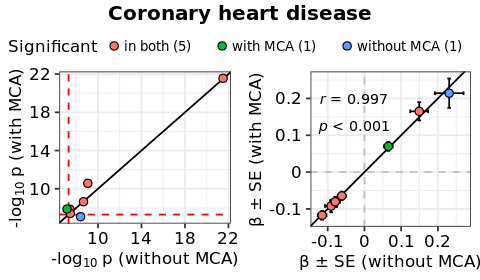

In [26]:
options(repr.plot.width = 8/2, repr.plot.height = 7/3)

plot_disease_pbeta("coronary_heart_disease", "Coronary heart disease")

In [29]:
make_fig4 <- function(){

    W <- 8
    H <- 8
    
    p1 <- plot_disease_pbeta("asthma", "Asthma")
    p2 <- plot_disease_pbeta("ckd", "Chronic kidney disease")
    p3 <- plot_disease_pbeta("coronary_heart_disease", "Coronary heart disease")
    p4 <- plot_disease_pbeta("hypercholesterolemia", "Hypercholesterolemia")
    p5 <- plot_disease_pbeta("breast_cancer", "Breast cancer")
    p6 <- plot_disease_pbeta("prostate_cancer", "Prostate cancer")
    
    final_plot <- ggdraw() +
        draw_plot(p1, x = 0 / W, y = ((14/3)+1) / H, width = 4 / W, height = (7/3) / H) +
        draw_plot(p2, x = 4 / W, y = ((14/3)+1) / H, width = 4 / W, height = (7/3) / H) +
        draw_plot(p3, x = 0 / W, y = ((7/3)+0.5) / H, width = 4 / W, height = (7/3) / H) +
        draw_plot(p4, x = 4 / W, y = ((7/3)+0.5) / H, width = 4 / W, height = (7/3) / H) +
        draw_plot(p5, x = 0 / W, y = 0 / H, width = 4 / W, height = (7/3) / H) +
        draw_plot(p6, x = 4 / W, y = 0 / H, width = 4 / W, height = (7/3) / H) +
    
    draw_plot_label(
        label = LETTERS[3:8],
        x = c(0, 4, 0, 4, 0, 4) / W,
        y = c((27/3)+1, (27/3)+1, (14/3)+0.5, (14/3)+0.5, 7/3, 7/3) / H,
        hjust = -0.2,
        vjust = 1.2,
        size = 15
    )
    
    return(final_plot)
}

Asthma :9.68304185826764e-20
Chronic kidney disease :1.17685917416037e-10
Coronary heart disease :6.35666450431942e-07
Hypercholesterolemia :4.81030174278496e-25
Breast cancer :4.85152489575348e-10
Prostate cancer :2.52199617974294e-13


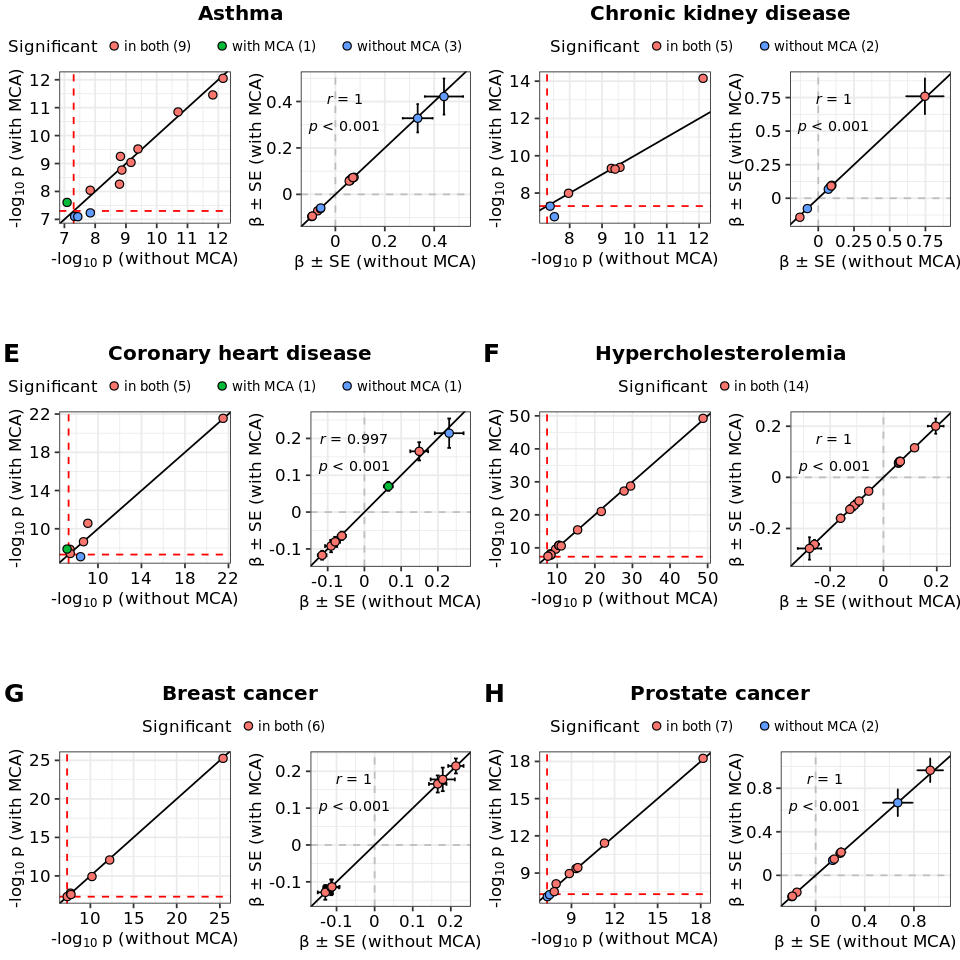

In [31]:
options(repr.plot.width = 8, repr.plot.height = 8)

fig4 <- make_fig4()
fig4

In [34]:
ggsave(
    paste0(fig.folder, "/fig4.tiff"),
    plot = fig4,
    device = "tiff",
    compression = 'lzw',
    bg = "white",
    dpi = 300,
    width = 8,
    height = 8,
    units = "in"
)

In [35]:
ggsave(
    paste0(fig.folder, "/fig4.pdf"),
    plot = fig4,
    device = cairo_pdf,
    width = 8,
    height = 8,
    units = "in"
)

# MCA-Variant Correlations

In [ ]:
gcs_path <- "gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/peaks_ped/"

raw_files <- system(
    paste("gsutil ls", paste0(gcs_path, "*.raw")),
    intern = TRUE
)

# Function to clean each .raw file
process_raw_file <- function(file) {

    dt <- fread_gcs_tsv(file) %>%
        rename(id = "IID") %>%
        select(-c("FID", "PAT", "MAT", "SEX", "PHENOTYPE")) %>%
    mutate(across(everything(), as.integer))

    # Remove substring "_" and everything after
    new_names <- sub("_.*$", "", names(dt))
    setnames(dt, names(dt), new_names)

    # Shift genotypes from 0/1/2 wrt REF allele to ALT allele
    marker_cols <- setdiff(names(dt), "id")
    dt[, (marker_cols) := lapply(.SD, function(x) 2L-x), .SDcols = marker_cols]

    return(dt)
}

# Read and clean all files
genotype_list <- lapply(raw_files, process_raw_file)

# Merge all by "id"
merged_genotype <- Reduce(function(x, y) merge(x, y, by = "id", all = TRUE),
                          genotype_list)

dim(merged_genotype)
colnames(merged_genotype)
head(merged_genotype)

In [ ]:
marker_cols <- setdiff(names(merged_genotype), "id")

for (variants in marker_cols){
    print(table(merged_genotype %>% pull(!!sym(variants))))
}

In [53]:
plot_disease_var.mca <- function(
    disease,
    pt_title,
    genotype = merged_genotype
){
    
    disease_peaks_df <- merge_disease(
        paste0(
            "gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/peaks/details_",
            disease,
            ".tsv"
        )
    )
    
    disease_peaks <- disease_peaks_df%>%
        pull(MarkerName)
    
    # Select only required peaks from the genotype file
    genotype_subset <- genotype %>%
        select(all_of(c("id", disease_peaks)))
    
    # Read MCA data from phenotype file and subset to main ancestries
    mca_data <- fread_gcs_tsv(
        paste0(
            "gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/",
            disease,
            "_mca/pheno_file/phenotype.tsv"
        )
    ) %>%
    filter(inf %in% c("AFR", "AMR", "EAS", "EUR", "SAS")) %>%
    select(all_of(c("id", paste0("mca_axis_", 0:19))))
    
    # Left join MCA stuff with genotype so we only consider people with MCA who were used in GWAS
    geno_mca <- mca_data %>%
        left_join(genotype_subset, by = "id") %>%
        select(-c("id"))
    
    # Define the matrix
    geno_mca_mat <- matrix(nrow = length(disease_peaks), ncol = 20)
    rownames(geno_mca_mat) <- disease_peaks
    colnames(geno_mca_mat) <- 1:ncol(geno_mca_mat)
    
    # This is a matrix of p-values
    p_geno_mca_mat <- geno_mca_mat
    
    for (i in rownames(geno_mca_mat)){
        for (j in colnames(geno_mca_mat)){
            
            correlation <- cor.test(
                x = geno_mca[[i]],
                y = geno_mca[[paste0("mca_axis_", (as.integer(j) - 1))]], 
                method = "pearson"
            )
            
            geno_mca_mat[i, j] <- (correlation$estimate)^2
            p_geno_mca_mat[i, j] <- correlation$p.value
            
        }
    }
    
    # Define annotation
    both_annot <- disease_peaks_df %>% filter(p_value.x < 5e-8 & p_value.y < 5e-8) %>% pull(MarkerName)
    with_annot <- disease_peaks_df %>% filter(p_value.x >= 5e-8 & p_value.y < 5e-8) %>% pull(MarkerName)
    without_annot <- disease_peaks_df %>% filter(p_value.x < 5e-8 & p_value.y >= 5e-8) %>% pull(MarkerName)
    
    # Create annotations in a datframe
    annot <- data.frame(rowname = rownames(geno_mca_mat)) %>%
        mutate(
            annots = case_when(
                rowname %in% both_annot ~ "Both",
                rowname %in% with_annot ~ "With MCA",
                rowname %in% without_annot ~ "Without MCA"
            )
        )
    
    # Order to match the rownames
    row_annotation <- rowAnnotation(
        annots = annot$annots,
        col = list(
            annots = c(
                "Both"        = "#F8766D",
                "With MCA"    = "#00BA38",
                "Without MCA" = "#619CFF"
            )
        ),
        show_annotation_name = FALSE,
        annotation_legend_param = list(
            title = "Genome-wide\nsignificant in",
            title_gp = gpar(fontsize = 16),
            labels_gp = gpar(fontsize = 14)
        )
    )
    
    hm_col_fun <- colorRamp2(seq(0, max(unlist(geno_mca_mat)), length.out = 100), viridis(100))

    ht <- Heatmap(
        geno_mca_mat,
        name = "r²",
        col = hm_col_fun,
        cluster_columns = FALSE,
        cluster_rows = FALSE,
        column_title = pt_title,
        column_title_side = "top",
        column_title_gp = gpar(fontsize = 20),
        column_names_rot = 0,
        column_names_centered = TRUE,
        column_names_gp = gpar(fontsize = 16),
        show_row_names = TRUE,
        row_names_side = "left",
        row_names_gp = gpar(fontsize = 16),
        rect_gp = gpar(col = "grey90", lwd = 0.4),
        border = TRUE,
        left_annotation = row_annotation,
        heatmap_legend_param = list(
            title_gp  = gpar(fontsize = 16, fontface = "bold"),
            labels_gp = gpar(fontsize = 14)
        )
    )
    
    draw(ht, padding = unit(c(5, 10, 5, 10), "mm"))   # top, right, bottom, left
}

In [54]:
p1 <- as.ggplot(function() plot_disease_var.mca("asthma", "Asthma"))
p2 <- as.ggplot(function() plot_disease_var.mca("ckd", "Chronic kidney disease"))
p3 <- as.ggplot(function() plot_disease_var.mca("coronary_heart_disease", "Coronary heart disease"))
p4 <- as.ggplot(function() plot_disease_var.mca("hypercholesterolemia", "Hypercholesterolemia"))
p5 <- as.ggplot(function() plot_disease_var.mca("breast_cancer", "Breast cancer"))
p6 <- as.ggplot(function() plot_disease_var.mca("prostate_cancer", "Prostate cancer"))

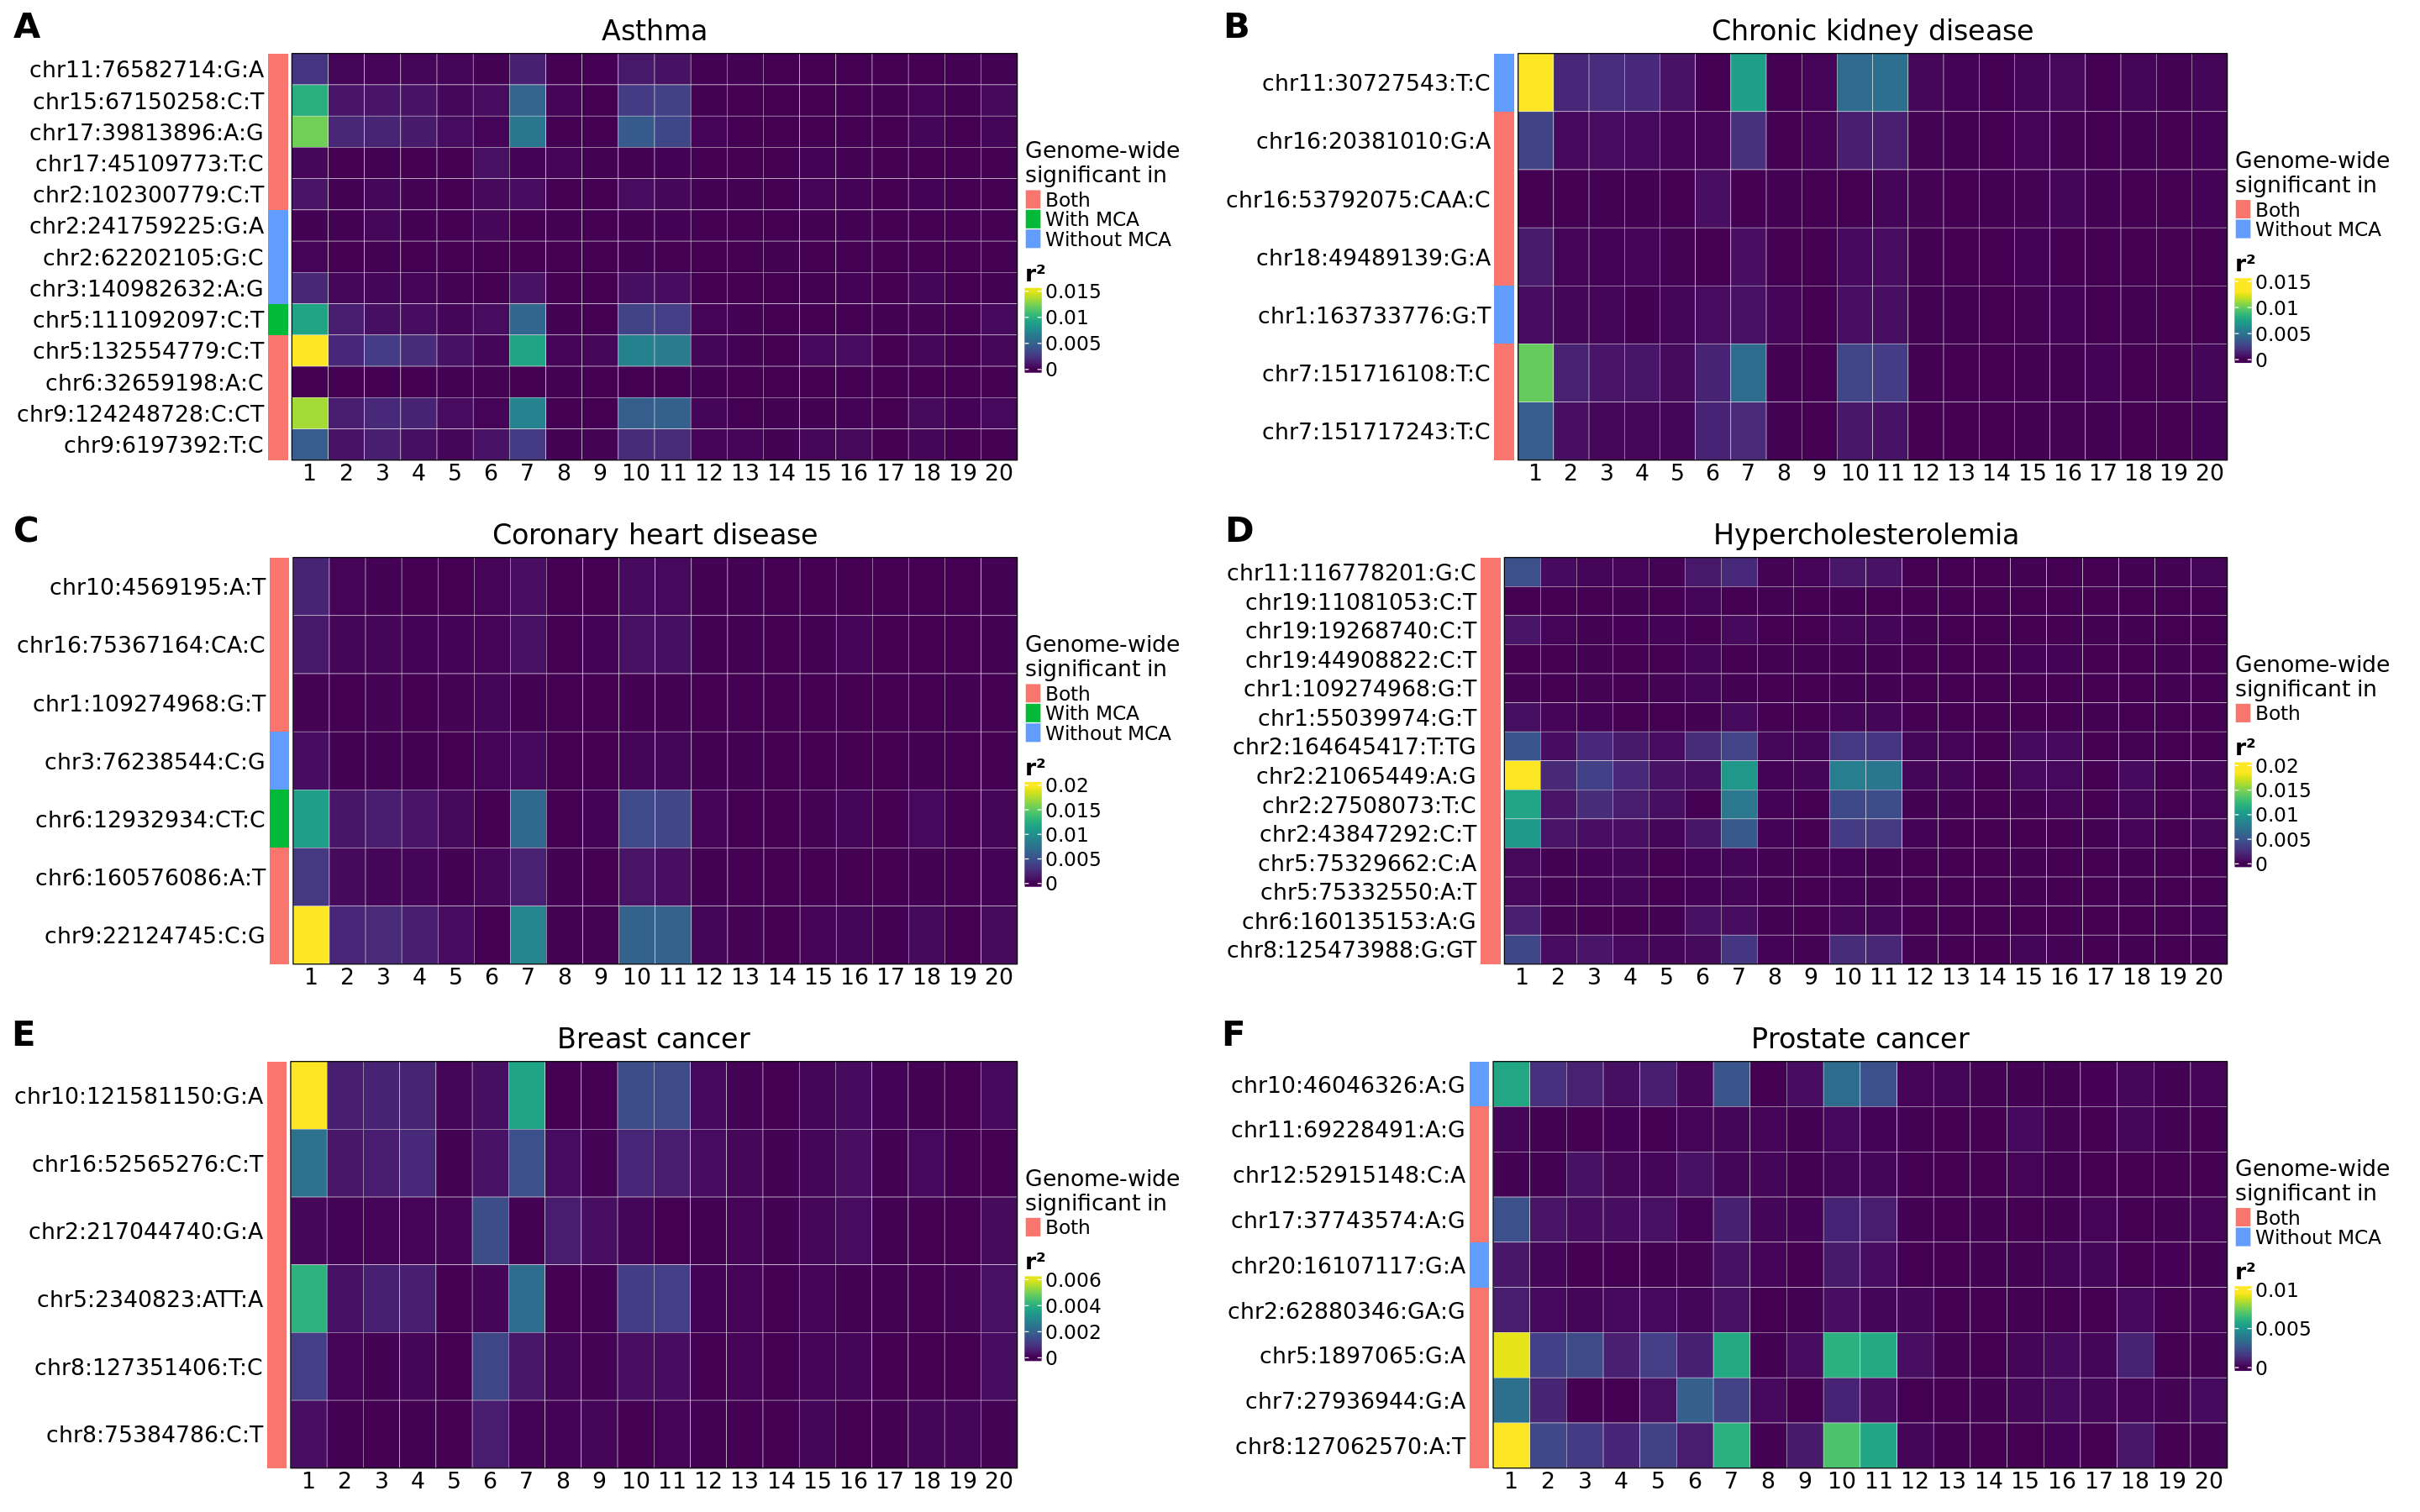

In [55]:
options(repr.plot.width = 12*2, repr.plot.height = 5*3)

mca_variant_correlation <- ggarrange(
    p1, p2, p3, p4, p5, p6,
    ncol = 2,
    nrow = 3,
    labels = LETTERS[1:6],
    font.label = list(size = 25)
)
mca_variant_correlation

In [56]:
ggsave(
    paste0(fig.folder, "/mca_variant_correlation.tiff"),
    plot = mca_variant_correlation,
    device = "tiff",
    compression = 'lzw',
    bg = "white",
    dpi = 300,
    width = 12*2,
    height = 5*3,
    units = "in"
)

# Combined Manhattan and QQ plots

In [7]:
create_panel <- function(manhattan_gs_uri, qq_gs_uri) {
    
    temp_man <- tempfile(fileext = ".tiff")
    temp_qq <- tempfile(fileext = ".tiff")

    
    on.exit(unlink(c(temp_man, temp_qq)))

    
    system2("gsutil", args = c("cp", manhattan_gs_uri, temp_man), stdout = FALSE, stderr = FALSE)
    system2("gsutil", args = c("cp", qq_gs_uri, temp_qq), stdout = FALSE, stderr = FALSE)

    
    img_man <- tiff::readTIFF(temp_man)
    img_qq <- tiff::readTIFF(temp_qq)

    
    grob_man <- rasterGrob(img_man, interpolate = TRUE)
    grob_qq <- rasterGrob(img_qq, interpolate = TRUE)

    
    plot_man <- ggplot() + annotation_custom(grob_man) + theme_void()
    plot_qq <- ggplot() + annotation_custom(grob_qq) + theme_void()

    
    row_panel <- ggarrange(plot_man, plot_qq, ncol = 2, nrow = 1)

    return(row_panel)
}

In [12]:
manhattan_uris <- paste0(
    "gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/figs/",
    c("asthma", "ckd", "coronary_heart_disease", "hypercholesterolemia", "breast_cancer", "prostate_cancer"),
    "_mca_manhattan.tiff"
)

qq_uris <- paste0(
    "gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/figs/",
    c("asthma", "ckd", "coronary_heart_disease", "hypercholesterolemia", "breast_cancer", "prostate_cancer"),
    "_mca_qq.tiff"
)


panels_list <- lapply(1:6, function(i) {
    create_panel(manhattan_uris[i], qq_uris[i])
})


final_plot <- ggarrange(
    plotlist = panels_list,
    ncol = 1,
    nrow = 6,
    labels = c(
        "A Asthma",
        "B Chronic kidney disease",
        "C Coronary heart disease",
        "D Hypercholesterolemia",
        "E Breast cancer",
        "F Prostate cancer"
    ),
    hjust = c(0,0,0),
    font.label = list(size = 18, face = "bold")
)

In [13]:
ggsave(
    paste0(fig.folder, "/mca_gwas.tiff"),
    plot = final_plot,
    device = "tiff",
    compression = 'lzw',
    bg = "white",
    dpi = 300,
    width = 9,
    height = 3*6,
    units = "in"
)

In [16]:
manhattan_uris <- paste0(
    "gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/figs/",
    c("asthma", "ckd", "coronary_heart_disease", "hypercholesterolemia", "breast_cancer", "prostate_cancer"),
    "_manhattan.tiff"
)

qq_uris <- paste0(
    "gs://fc-secure-1792472b-ed73-4937-b557-928a360bc420/data/meta/SDoH_MCA_GWAS/figs/",
    c("asthma", "ckd", "coronary_heart_disease", "hypercholesterolemia", "breast_cancer", "prostate_cancer"),
    "_qq.tiff"
)


panels_list <- lapply(1:6, function(i) {
    create_panel(manhattan_uris[i], qq_uris[i])
})


final_plot <- ggarrange(
    plotlist = panels_list,
    ncol = 1,
    nrow = 6,
    labels = c(
        "A Asthma",
        "B Chronic kidney disease",
        "C Coronary heart disease",
        "D Hypercholesterolemia",
        "E Breast cancer",
        "F Prostate cancer"
    ),
    hjust = c(0,0,0),
    font.label = list(size = 18, face = "bold")
)

In [17]:
ggsave(
    paste0(fig.folder, "/no_mca_gwas.tiff"),
    plot = final_plot,
    device = "tiff",
    compression = 'lzw',
    bg = "white",
    dpi = 300,
    width = 9,
    height = 3*6,
    units = "in"
)